<div style="text-align: right">   </div>


Introduction to Deep Learning (2023) &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;&nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;&nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;&nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;&nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;| &nbsp;
-------|-------------------
**Assignment 2 - Recurrent Neural Networks** | <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/b/b0/UniversiteitLeidenLogo.svg/1280px-UniversiteitLeidenLogo.svg.png" width="300">



# Introduction


The goal of this assignment is to learn how to use encoder-decoder recurrent neural networks (RNNs). Specifically we will be dealing with a sequence to sequence problem and try to build recurrent models that can learn the principles behind simple arithmetic operations (**integer addition, subtraction and multiplication.**).

<img src="https://i.ibb.co/5Ky5pbk/Screenshot-2023-11-10-at-07-51-21.png" alt="Screenshot-2023-11-10-at-07-51-21" border="0" width="500"></a>

In this assignment you will be working with three different kinds of models, based on input/output data modalities:
1. **Text-to-text**: given a text query containing two integers and an operand between them (+ or -) the model's output should be a sequence of integers that match the actual arithmetic result of this operation
2. **Image-to-text**: same as above, except the query is specified as a sequence of images containing individual digits and an operand.
3. **Text-to-image**: the query is specified in text format as in the text-to-text model, however the model's output should be a sequence of images corresponding to the correct result.


### Description**
Let us suppose that we want to develop a neural network that learns how to add or subtract
two integers that are at most two digits long. For example, given input strings of 5 characters: ‘81+24’ or
’41-89’ that consist of 2 two-digit long integers and an operand between them, the network should return a
sequence of 3 characters: ‘105 ’ or ’-48 ’ that represent the result of their respective queries. Additionally,
we want to build a model that generalizes well - if the network can extract the underlying principles behind
the ’+’ and ’-’ operands and associated operations, it should not need too many training examples to generate
valid answers to unseen queries. To represent such queries we need 13 unique characters: 10 for digits (0-9),
2 for the ’+’ and ’-’ operands and one for whitespaces ’ ’ used as padding.
The example above describes a text-to-text sequence mapping scenario. However, we can also use different
modalities of data to represent our queries or answers. For that purpose, the MNIST handwritten digit
dataset is going to be used again, however in a slightly different format. The functions below will be used to create our datasets.

---

*To work on this notebook you should create a copy of it.*


# Function definitions for creating the datasets

First we need to create our datasets that are going to be used for training our models.

In order to create image queries of simple arithmetic operations such as '15+13' or '42-10' we need to create images of '+' and '-' signs using ***open-cv*** library. We will use these operand signs together with the MNIST dataset to represent the digits.

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import numpy as np
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Dense, LSTM, TimeDistributed
from tensorflow.keras.layers import RepeatVector, Reshape, Conv2DTranspose, LayerNormalization, BatchNormalization, Dense
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split




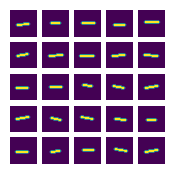

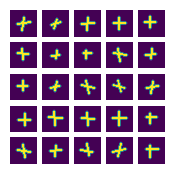

In [2]:
from scipy.ndimage import rotate
# Create plus/minus operand signs
def generate_images(number_of_images=50, sign='-'):

    blank_images = np.zeros([number_of_images, 28, 28])  # Dimensionality matches the size of MNIST images (28x28)
    x = np.random.randint(12, 16, (number_of_images, 2)) # Randomized x coordinates
    y1 = np.random.randint(6, 10, number_of_images)       # Randomized y coordinates
    y2 = np.random.randint(18, 22, number_of_images)     # -||-

    for i in range(number_of_images): # Generate n different images
        cv2.line(blank_images[i], (y1[i], x[i,0]), (y2[i], x[i, 1]), (255,0,0), 2, cv2.LINE_AA)     # Draw lines with randomized coordinates
        if sign == '+':
            cv2.line(blank_images[i], (x[i,0], y1[i]), (x[i, 1], y2[i]), (255,0,0), 2, cv2.LINE_AA) # Draw lines with randomized coordinates
        if sign == '*':
            cv2.line(blank_images[i], (x[i,0], y1[i]), (x[i, 1], y2[i]), (255,0,0), 2, cv2.LINE_AA)
            # Rotate 45 degrees
            blank_images[i] = rotate(blank_images[i], -50, reshape=False)
            cv2.line(blank_images[i], (x[i,0], y1[i]), (x[i, 1], y2[i]), (255,0,0), 2, cv2.LINE_AA)
            blank_images[i] = rotate(blank_images[i], -50, reshape=False)
            cv2.line(blank_images[i], (x[i,0], y1[i]), (x[i, 1], y2[i]), (255,0,0), 2, cv2.LINE_AA)

    return blank_images

def show_generated(images, n=5):
    plt.figure(figsize=(2, 2))
    for i in range(n**2):
        plt.subplot(n, n, i+1)
        plt.axis('off')
        plt.imshow(images[i])
    plt.show()

show_generated(generate_images())
show_generated(generate_images(sign='+'))

In [3]:
def create_data(highest_integer, num_addends=2, operands=['+', '-']):
    """
    Creates the following data for all pairs of integers up to [1:highest integer][+/-][1:highest_integer]:

    @return:
    X_text: '51+21' -> text query of an arithmetic operation (5)
    X_img : Stack of MNIST images corresponding to the query (5 x 28 x 28) -> sequence of 5 images of size 28x28
    y_text: '72' -> answer of the arithmetic text query
    y_img :  Stack of MNIST images corresponding to the answer (3 x 28 x 28)

    Images for digits are picked randomly from the whole MNIST dataset.
    """

    num_indices = [np.where(MNIST_labels==x) for x in range(10)]
    num_data = [MNIST_data[inds] for inds in num_indices]
    image_mapping = dict(zip(unique_characters[:10], num_data))
    image_mapping['-'] = generate_images()
    image_mapping['+'] = generate_images(sign='+')
    image_mapping['*'] = generate_images(sign='*')
    image_mapping[' '] = np.zeros([1, 28, 28])

    X_text, X_img, y_text, y_img = [], [], [], []

    for i in range(highest_integer + 1):      # First addend
        for j in range(highest_integer + 1):  # Second addend
            for sign in operands: # Create all possible combinations of operands
                query_string = to_padded_chars(str(i) + sign + str(j), max_len=max_query_length, pad_right=True)
                query_image = []
                for n, char in enumerate(query_string):
                    image_set = image_mapping[char]
                    index = np.random.randint(0, len(image_set), 1)
                    query_image.append(image_set[index].squeeze())

                result = eval(query_string)
                result_string = to_padded_chars(result, max_len=max_answer_length, pad_right=True)
                result_image = []
                for n, char in enumerate(result_string):
                    image_set = image_mapping[char]
                    index = np.random.randint(0, len(image_set), 1)
                    result_image.append(image_set[index].squeeze())

                X_text.append(query_string)
                X_img.append(np.stack(query_image))
                y_text.append(result_string)
                y_img.append(np.stack(result_image))

    return np.stack(X_text), np.stack(X_img)/255., np.stack(y_text), np.stack(y_img)/255.

def to_padded_chars(integer, max_len=3, pad_right=False):
    """
    Returns a string of len()=max_len, containing the integer padded with ' ' on either right or left side
    """
    length = len(str(integer))
    padding = (max_len - length) * ' '
    if pad_right:
        return str(integer) + padding
    else:
        return padding + str(integer)


# Creating our data

The dataset consists of 20000 samples that (additions and subtractions between all 2-digit integers) and they have two kinds of inputs and label modalities:

  **X_text**: strings containing queries of length 5: ['  1+1  ', '11-18', ...]

  **X_image**: a stack of images representing a single query, dimensions: [5, 28, 28]

  **y_text**: strings containing answers of length 3: ['  2', '156']

  **y_image**: a stack of images that represents the answer to a query, dimensions: [3, 28, 28]

11490434/11490434 [==============================] - 1s 0us/step
(20000,) (20000, 5, 28, 28) (20000,) (20000, 3, 28, 28)
Query #320

X_text: "1+60 " = y_text: "61 "


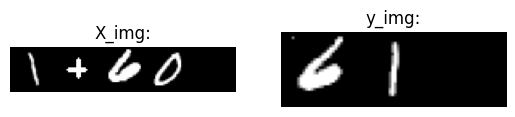

Query #4797

X_text: "23-98" = y_text: "-75"


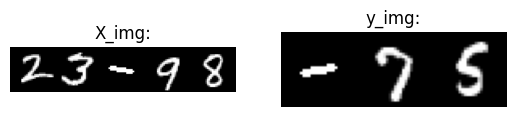

Query #505

X_text: "2-52 " = y_text: "-50"


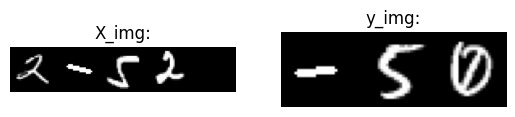

Query #382

X_text: "1+91 " = y_text: "92 "


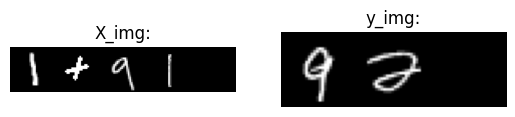

Query #8909

X_text: "44-54" = y_text: "-10"


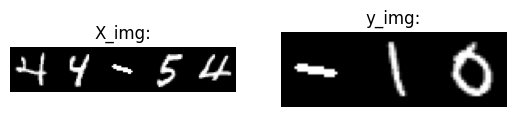

Query #8217

X_text: "41-8 " = y_text: "33 "


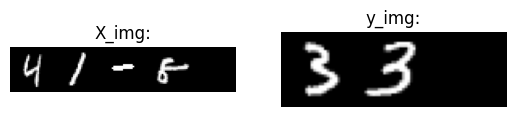

Query #8041

X_text: "40-20" = y_text: "20 "


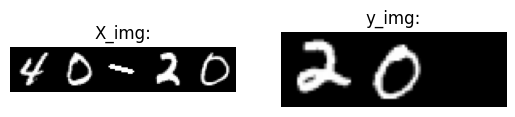

Query #3618

X_text: "18+9 " = y_text: "27 "


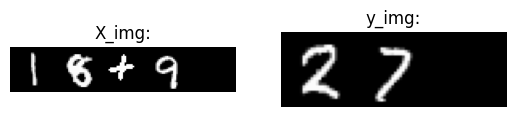

Query #6346

X_text: "31+73" = y_text: "104"


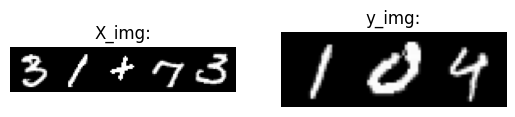

Query #9782

X_text: "48+91" = y_text: "139"


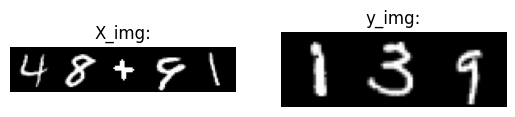

In [4]:
# Illustrate the generated query/answer pairs

unique_characters = '0123456789+- '       # All unique characters that are used in the queries (13 in total: digits 0-9, 2 operands [+, -], and a space character ' '.)
highest_integer = 99                      # Highest value of integers contained in the queries

max_int_length = len(str(highest_integer))# Maximum number of characters in an integer
max_query_length = max_int_length * 2 + 1 # Maximum length of the query string (consists of two integers and an operand [e.g. '22+10'])
max_answer_length = 3    # Maximum length of the answer string (the longest resulting query string is ' 1-99'='-98')

# Create the data (might take around a minute)
(MNIST_data, MNIST_labels), _ = tf.keras.datasets.mnist.load_data()
X_text, X_img, y_text, y_img = create_data(highest_integer)
print(X_text.shape, X_img.shape, y_text.shape, y_img.shape)


## Display the samples that were created
def display_sample(n):
    labels = ['X_img:', 'y_img:']
    for i, data in enumerate([X_img, y_img]):
        plt.subplot(1,2,i+1)
        # plt.set_figheight(15)
        plt.axis('off')
        plt.title(labels[i])
        plt.imshow(np.hstack(data[n]), cmap='gray')
    print('='*50, f'\nQuery #{n}\n\nX_text: "{X_text[n]}" = y_text: "{y_text[n]}"')
    plt.show()

for _ in range(10):
    display_sample(np.random.randint(0, 10000, 1)[0])

## Helper functions

The functions below will help with input/output of the data.

In [5]:
# One-hot encoding/decoding the text queries/answers so that they can be processed using RNNs
# You should use these functions to convert your strings and read out the output of your networks

def encode_labels(labels, max_len=3):
  n = len(labels)
  length = len(labels[0])
  char_map = dict(zip(unique_characters, range(len(unique_characters))))
  one_hot = np.zeros([n, length, len(unique_characters)])
  for i, label in enumerate(labels):
      m = np.zeros([length, len(unique_characters)])
      for j, char in enumerate(label):
          m[j, char_map[char]] = 1
      one_hot[i] = m

  return one_hot


def decode_labels(labels):
    pred = np.argmax(labels, axis=1)
    predicted = ''.join([unique_characters[i] for i in pred])

    return predicted

X_text_onehot = encode_labels(X_text)
y_text_onehot = encode_labels(y_text)

print(X_text_onehot.shape, y_text_onehot.shape)

(20000, 5, 13) (20000, 3, 13)


---
---

## I. Text-to-text RNN model

The following code showcases how Recurrent Neural Networks (RNNs) are built using Keras. Several new layers are going to be used:

1. LSTM
2. TimeDistributed
3. RepeatVector

The code cell below explains each of these new components.

<img src="https://i.ibb.co/NY7FFTc/Screenshot-2023-11-10-at-09-27-25.png" alt="Screenshot-2023-11-10-at-09-27-25" border="0" width="500"></a>


In [ ]:
def build_text2text_model():

    # We start by initializing a sequential model
    text2text = tf.keras.Sequential()

    # "Encode" the input sequence using an RNN, producing an output of size 256.
    # In this case the size of our input vectors is [5, 13] as we have queries of length 5 and 13 unique characters. Each of these 5 elements in the query will be fed to the network one by one,
    # as shown in the image above (except with 5 elements).
    # Hint: In other applications, where your input sequences have a variable length (e.g. sentences), you would use input_shape=(None, unique_characters).
    text2text.add(LSTM(256, input_shape=(None, len(unique_characters))))

    # As the decoder RNN's input, repeatedly provide with the last output of RNN for each time step. Repeat 3 times as that's the maximum length of the output (e.g. '  1-99' = '-98')
    # when using 2-digit integers in queries. In other words, the RNN will always produce 3 characters as its output.
    text2text.add(RepeatVector(max_answer_length))

    # By setting return_sequences to True, return not only the last output but all the outputs so far in the form of (num_samples, timesteps, output_dim). This is necessary as TimeDistributed in the below expects
    # the first dimension to be the timesteps.
    text2text.add(LSTM(256, return_sequences=True))

    # Apply a dense layer to the every temporal slice of an input. For each of step of the output sequence, decide which character should be chosen.
    text2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    # Next we compile the model using categorical crossentropy as our loss function.
    text2text.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    text2text.summary()

    return text2text

Split: 25% test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_text_onehot, y_text_onehot, test_size=0.25, random_state=0)
text2text = build_text2text_model()
history=text2text.fit(X_train,y_train,epochs=10,batch_size=10, validation_split=0.1)
results25_accuracy = history.history['accuracy']
results25_loss = history.history['loss']
results25 = text2text.evaluate(X_test, y_test)
print("test loss, test acc:", results25)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 256)               276480    
                                                                 
 repeat_vector (RepeatVecto  (None, 3, 256)            0         
 r)                                                              
                                                                 
 lstm_1 (LSTM)               (None, 3, 256)            525312    
                                                                 
 time_distributed (TimeDist  (None, 3, 13)             3341      
 ributed)                                                        
                                                                 
Total params: 805133 (3.07 MB)
Trainable params: 805133 (3.07 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
1350/1350

In [ ]:
predictions = text2text.predict(X_test)

decoded_predictions = [decode_labels(pred) for pred in predictions]
decoded_true_labels = [decode_labels(true) for true in y_test]

for i in range (predictions.shape[0]):
    if decoded_true_labels[i] != decoded_predictions[i]:
        print(f'Query: {decode_labels(X_test[i])} \nPrediction: {decoded_predictions[i]} \nTrue answer: {decoded_true_labels[i]} \n')



157/157 [==============================] - 1s 3ms/step
Query: 24-90 
Prediction: -67 
True answer: -66 

Query: 1+15  
Prediction: 17  
True answer: 16  

Query: 8+12  
Prediction: 19  
True answer: 20  

Query: 67-7  
Prediction: 50  
True answer: 60  

Query: 73-79 
Prediction: -7  
True answer: -6  

Query: 0-25  
Prediction: -28 
True answer: -25 

Query: 68-61 
Prediction: 8   
True answer: 7   

Query: 97-78 
Prediction: 29  
True answer: 19  

Query: 34+5  
Prediction: 49  
True answer: 39  

Query: 11-42 
Prediction: -32 
True answer: -31 

Query: 1-92  
Prediction: -90 
True answer: -91 

Query: 26-5  
Prediction: 22  
True answer: 21  

Query: 48-0  
Prediction: 47  
True answer: 48  

Query: 62-0  
Prediction: 63  
True answer: 62  

Query: 50-66 
Prediction: -17 
True answer: -16 

Query: 44-83 
Prediction: -49 
True answer: -39 

Query: 92-3  
Prediction: 90  
True answer: 89  

Query: 42+11 
Prediction: 54  
True answer: 53  

Query: 3-58  
Prediction: -54 
True answer: -

Split: 50% test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_text_onehot, y_text_onehot, test_size=0.5, random_state=0)
text2text = build_text2text_model()
history=text2text.fit(X_train,y_train,epochs=10,batch_size=10, validation_split=0.1)
results50_accuracy = history.history['accuracy']
results50_loss = history.history['loss']
results50 = text2text.evaluate(X_test, y_test)
print("test loss, test acc:", results50)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 256)               276480    
                                                                 
 repeat_vector_1 (RepeatVec  (None, 3, 256)            0         
 tor)                                                            
                                                                 
 lstm_3 (LSTM)               (None, 3, 256)            525312    
                                                                 
 time_distributed_1 (TimeDi  (None, 3, 13)             3341      
 stributed)                                                      
                                                                 
Total params: 805133 (3.07 MB)
Trainable params: 805133 (3.07 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
900/900

In [ ]:
predictions = text2text.predict(X_test)

decoded_predictions = [decode_labels(pred) for pred in predictions]
decoded_true_labels = [decode_labels(true) for true in y_test]

for i in range (predictions.shape[0]):
    if decoded_true_labels[i] != decoded_predictions[i]:
        print(f'Query: {decode_labels(X_test[i])} \nPrediction: {decoded_predictions[i]} \nTrue answer: {decoded_true_labels[i]} \n')

Η έξοδος ροής περικόπηκε στις τελευταίες 5000 γραμμές.
Query: 49+80 
Prediction: 138 
True answer: 129 

Query: 2+9   
Prediction: 1   
True answer: 11  

Query: 46+84 
Prediction: 138 
True answer: 130 

Query: 87-64 
Prediction: 24  
True answer: 23  

Query: 5+4   
Prediction: 1   
True answer: 9   

Query: 49-34 
Prediction: 11  
True answer: 15  

Query: 70+15 
Prediction: 86  
True answer: 85  

Query: 34-76 
Prediction: -44 
True answer: -42 

Query: 93-19 
Prediction: 69  
True answer: 74  

Query: 83+11 
Prediction: 90  
True answer: 94  

Query: 74+20 
Prediction: 96  
True answer: 94  

Query: 78+61 
Prediction: 148 
True answer: 139 

Query: 63-16 
Prediction: 41  
True answer: 47  

Query: 18-63 
Prediction: -47 
True answer: -45 

Query: 82+46 
Prediction: 138 
True answer: 128 

Query: 99-0  
Prediction: 81  
True answer: 99  

Query: 94-88 
Prediction: 1   
True answer: 6   

Query: 47-22 
Prediction: 26  
True answer: 25  

Query: 88-75 
Prediction: 11  
True answer: 1

Split: 75% test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_text_onehot, y_text_onehot, test_size=0.75, random_state=0)
text2text = build_text2text_model()
history=text2text.fit(X_train,y_train,epochs=10,batch_size=10,validation_split=0.1)
results75_accuracy = history.history['accuracy']
results75_loss = history.history['loss']
results75 = text2text.evaluate(X_test, y_test)
print("test loss, test acc:", results75)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 256)               276480    
                                                                 
 repeat_vector_2 (RepeatVec  (None, 3, 256)            0         
 tor)                                                            
                                                                 
 lstm_5 (LSTM)               (None, 3, 256)            525312    
                                                                 
 time_distributed_2 (TimeDi  (None, 3, 13)             3341      
 stributed)                                                      
                                                                 
Total params: 805133 (3.07 MB)
Trainable params: 805133 (3.07 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
450/450

In [ ]:
predictions = text2text.predict(X_test)

decoded_predictions = [decode_labels(pred) for pred in predictions]
decoded_true_labels = [decode_labels(true) for true in y_test]
for i in range (predictions.shape[0]):
    if decoded_true_labels[i] != decoded_predictions[i]:
        print(f'Query: {decode_labels(X_test[i])} \nPrediction: {decoded_predictions[i]} \nTrue answer: {decoded_true_labels[i]} \n')


Η έξοδος ροής περικόπηκε στις τελευταίες 5000 γραμμές.
Query: 21-35 
Prediction: -13 
True answer: -14 

Query: 77-3  
Prediction: 71  
True answer: 74  

Query: 24+60 
Prediction: 93  
True answer: 84  

Query: 76-93 
Prediction: -13 
True answer: -17 

Query: 83+72 
Prediction: 154 
True answer: 155 

Query: 28+78 
Prediction: 117 
True answer: 106 

Query: 55+74 
Prediction: 133 
True answer: 129 

Query: 77+92 
Prediction: 163 
True answer: 169 

Query: 62-41 
Prediction: 22  
True answer: 21  

Query: 78-17 
Prediction: 77  
True answer: 61  

Query: 40+85 
Prediction: 123 
True answer: 125 

Query: 85-37 
Prediction: 47  
True answer: 48  

Query: 11+21 
Prediction: 27  
True answer: 32  

Query: 1+45  
Prediction: 47  
True answer: 46  

Query: 98+54 
Prediction: 154 
True answer: 152 

Query: 40+66 
Prediction: 117 
True answer: 106 

Query: 5+24  
Prediction: 37  
True answer: 29  

Query: 96-60 
Prediction: 47  
True answer: 36  

Query: 16+96 
Prediction: 117 
True answer: 1

Split: 90% test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_text_onehot, y_text_onehot, test_size=0.90, random_state=0)
text2text = build_text2text_model()
history=text2text.fit(X_train,y_train,epochs=10,batch_size=10,validation_split=0.1)
results90_accuracy = history.history['accuracy']
results90_loss = history.history['loss']
results90 = text2text.evaluate(X_test, y_test)
print("test loss, test acc:", results90)

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 256)               276480    
                                                                 
 repeat_vector_3 (RepeatVec  (None, 3, 256)            0         
 tor)                                                            
                                                                 
 lstm_7 (LSTM)               (None, 3, 256)            525312    
                                                                 
 time_distributed_3 (TimeDi  (None, 3, 13)             3341      
 stributed)                                                      
                                                                 
Total params: 805133 (3.07 MB)
Trainable params: 805133 (3.07 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
180/180

In [ ]:
predictions = text2text.predict(X_test)

decoded_predictions = [decode_labels(pred) for pred in predictions]
decoded_true_labels = [decode_labels(true) for true in y_test]
for i in range (predictions.shape[0]):
    if decoded_true_labels[i] != decoded_predictions[i]:
        print(f'Query: {decode_labels(X_test[i])} \nPrediction: {decoded_predictions[i]} \nTrue answer: {decoded_true_labels[i]} \n')

Η έξοδος ροής περικόπηκε στις τελευταίες 5000 γραμμές.
Query: 73+31 
Prediction: 111 
True answer: 104 

Query: 11+50 
Prediction: 44  
True answer: 61  

Query: 35-30 
Prediction: 1   
True answer: 5   

Query: 36-85 
Prediction: -47 
True answer: -49 

Query: 63+73 
Prediction: 140 
True answer: 136 

Query: 43-86 
Prediction: -40 
True answer: -43 

Query: 42+98 
Prediction: 135 
True answer: 140 

Query: 56+47 
Prediction: 111 
True answer: 103 

Query: 39-32 
Prediction: 1   
True answer: 7   

Query: 5+23  
Prediction: 40  
True answer: 28  

Query: 70-42 
Prediction: 25  
True answer: 28  

Query: 2+34  
Prediction: 44  
True answer: 36  

Query: 57-23 
Prediction: 45  
True answer: 34  

Query: 43+54 
Prediction: 104 
True answer: 97  

Query: 35+16 
Prediction: 40  
True answer: 51  

Query: 1-82  
Prediction: -77 
True answer: -81 

Query: 43+99 
Prediction: 145 
True answer: 142 

Query: 72+12 
Prediction: 90  
True answer: 84  

Query: 15+22 
Prediction: 40  
True answer: 3

Plot 1

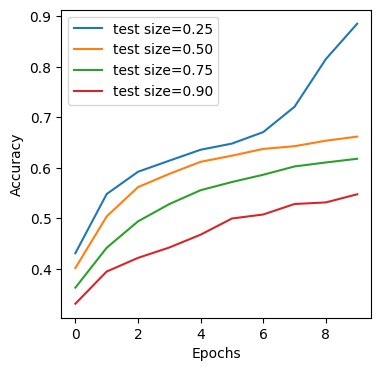

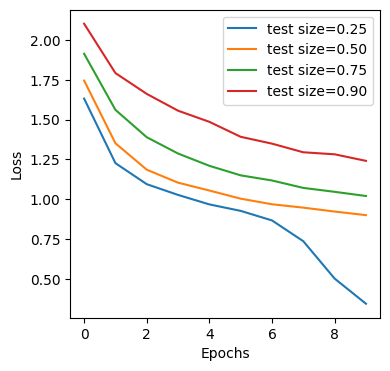

In [ ]:
plt.figure(figsize=(4,4))
plt.plot(results25_accuracy, label="test size=0.25")
plt.plot(results50_accuracy, label="test size=0.50")
plt.plot(results75_accuracy, label="test size=0.75")
plt.plot(results90_accuracy, label="test size=0.90")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('text2text_accuracy.png', bbox_inches="tight")
plt.show()

plt.figure(figsize=(4,4))
plt.plot(results25_loss, label="test size=0.25")
plt.plot(results50_loss, label="test size=0.50")
plt.plot(results75_loss, label="test size=0.75")
plt.plot(results90_loss, label="test size=0.90")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('text2text_loss.png', bbox_inches="tight")
plt.show()

Second text-to-text model with additional LSTM layers

In [ ]:
def build_second_text2text_model():
    second_text2text = tf.keras.Sequential()
    second_text2text.add(LSTM(256, input_shape=(None, len(unique_characters)), return_sequences=True))
    second_text2text.add(LayerNormalization())
    second_text2text.add(LSTM(256,))
    second_text2text.add(RepeatVector(max_answer_length))

    second_text2text.add(LSTM(128,))
    second_text2text.add(LayerNormalization())

    second_text2text.add(RepeatVector(max_answer_length))

    second_text2text.add(LSTM(128, return_sequences=True))

    second_text2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    second_text2text.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    second_text2text.summary()

    return second_text2text

Split: 25% test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_text_onehot, y_text_onehot, test_size=0.25, random_state=0)
second_text2text = build_second_text2text_model()
history=second_text2text.fit(X_train,y_train,epochs=10,batch_size=10,validation_split=0.1)
second_results25_accuracy = history.history['accuracy']
second_results25_loss = history.history['loss']
second_results25 = second_text2text.evaluate(X_test, y_test)
print("test loss, test acc:", second_results25)

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_8 (LSTM)               (None, None, 256)         276480    
                                                                 
 layer_normalization (Layer  (None, None, 256)         512       
 Normalization)                                                  
                                                                 
 lstm_9 (LSTM)               (None, 256)               525312    
                                                                 
 repeat_vector_4 (RepeatVec  (None, 3, 256)            0         
 tor)                                                            
                                                                 
 lstm_10 (LSTM)              (None, 128)               197120    
                                                                 
 layer_normalization_1 (Lay  (None, 128)              

Split: 50% test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_text_onehot, y_text_onehot, test_size=0.50,random_state=0)
second_text2text = build_second_text2text_model()
history=second_text2text.fit(X_train,y_train,epochs=10,batch_size=10,validation_split=0.1)
second_results50_accuracy = history.history['accuracy']
second_results50_loss = history.history['loss']
second_results50 = second_text2text.evaluate(X_test, y_test)
print("test loss, test acc:", second_results50)

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_12 (LSTM)              (None, None, 256)         276480    
                                                                 
 layer_normalization_2 (Lay  (None, None, 256)         512       
 erNormalization)                                                
                                                                 
 lstm_13 (LSTM)              (None, 256)               525312    
                                                                 
 repeat_vector_6 (RepeatVec  (None, 3, 256)            0         
 tor)                                                            
                                                                 
 lstm_14 (LSTM)              (None, 128)               197120    
                                                                 
 layer_normalization_3 (Lay  (None, 128)              

Split: 75% test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_text_onehot, y_text_onehot, test_size=0.75,random_state=0)
second_text2text = build_second_text2text_model()
history=second_text2text.fit(X_train,y_train,epochs=10,batch_size=10,validation_split=0.1)
second_results75_accuracy = history.history['accuracy']
second_results75_loss = history.history['loss']
second_results75 = second_text2text.evaluate(X_test, y_test)
print("test loss, test acc:", second_results75)

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_16 (LSTM)              (None, None, 256)         276480    
                                                                 
 layer_normalization_4 (Lay  (None, None, 256)         512       
 erNormalization)                                                
                                                                 
 lstm_17 (LSTM)              (None, 256)               525312    
                                                                 
 repeat_vector_8 (RepeatVec  (None, 3, 256)            0         
 tor)                                                            
                                                                 
 lstm_18 (LSTM)              (None, 128)               197120    
                                                                 
 layer_normalization_5 (Lay  (None, 128)              

Split: 90% test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_text_onehot, y_text_onehot, test_size=0.90, random_state=0)
second_text2text = build_second_text2text_model()
history=second_text2text.fit(X_train,y_train,epochs=10,batch_size=10,validation_split=0.1)
second_results90_accuracy = history.history['accuracy']
second_results90_loss = history.history['loss']
second_results90 = second_text2text.evaluate(X_test, y_test)
print("test loss, test acc:", second_results90)

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_20 (LSTM)              (None, None, 256)         276480    
                                                                 
 layer_normalization_6 (Lay  (None, None, 256)         512       
 erNormalization)                                                
                                                                 
 lstm_21 (LSTM)              (None, 256)               525312    
                                                                 
 repeat_vector_10 (RepeatVe  (None, 3, 256)            0         
 ctor)                                                           
                                                                 
 lstm_22 (LSTM)              (None, 128)               197120    
                                                                 
 layer_normalization_7 (Lay  (None, 128)              

Plot 2

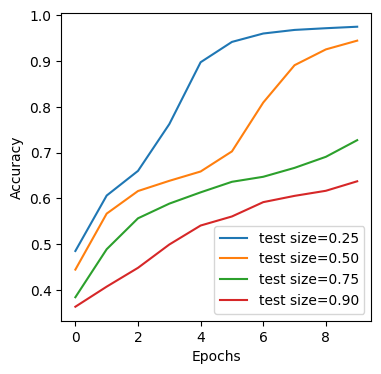

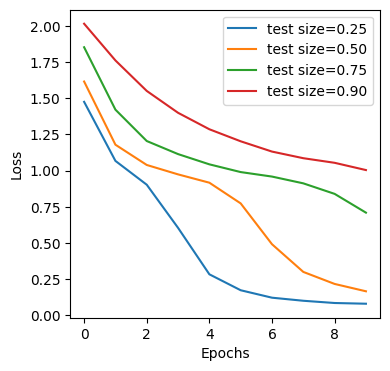

In [ ]:
plt.figure(figsize=(4,4))
plt.plot(second_results25_accuracy, label="test size=0.25")
plt.plot(second_results50_accuracy, label="test size=0.50")
plt.plot(second_results75_accuracy, label="test size=0.75")
plt.plot(second_results90_accuracy, label="test size=0.90")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('additional_text2text_accuracy.png', bbox_inches="tight")
plt.show()

plt.figure(figsize=(4,4))
plt.plot(second_results25_loss, label="test size=0.25")
plt.plot(second_results50_loss, label="test size=0.50")
plt.plot(second_results75_loss, label="test size=0.75")
plt.plot(second_results90_loss, label="test size=0.90")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('additional_text2text_loss.png', bbox_inches="tight")
plt.show()


---
---

## II. Image to text RNN Model

Hint: There are two ways of building the encoder for such a model - again by using the regular LSTM cells (with flattened images as vectors) or recurrect convolutional layers [ConvLSTM2D](https://keras.io/api/layers/recurrent_layers/conv_lstm2d/).

The goal here is to use **X_img** as inputs and **y_text** as outputs.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_img, y_text_onehot, test_size=0.25, random_state=0)

X_train_flatten = X_train.reshape(X_train.shape[0], X_train.shape[1],-1)
print(X_train_flatten.shape)
X_test_flatten = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)
print(X_test_flatten.shape)

img2text = tf.keras.Sequential()

img2text.add(LSTM(256, input_shape=(None, 784)))
img2text.add(RepeatVector(max_answer_length))
img2text.add(LSTM(256, return_sequences=True))
img2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))
img2text.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
img2text.summary()

history=img2text.fit(X_train_flatten, y_train, epochs=25, batch_size=10,validation_split=0.1)
init_results_acc = history.history['accuracy']
init_results_loss = history.history['loss']
results1 = img2text.evaluate(X_test_flatten, y_test)
print("test loss, test acc:", results1)

(15000, 5, 784)
(5000, 5, 784)
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 256)               1065984   
                                                                 
 repeat_vector_1 (RepeatVec  (None, 3, 256)            0         
 tor)                                                            
                                                                 
 lstm_3 (LSTM)               (None, 3, 256)            525312    
                                                                 
 time_distributed_1 (TimeDi  (None, 3, 13)             3341      
 stributed)                                                      
                                                                 
Total params: 1594637 (6.08 MB)
Trainable params: 1594637 (6.08 MB)
Non-trainable params: 0 (0.00 Byte)
___________________________________________________

one-extra layer

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_img, y_text_onehot, test_size=0.25, random_state=0)

X_train_flatten = X_train.reshape(X_train.shape[0], X_train.shape[1],-1)
print(X_train_flatten.shape)
X_test_flatten = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)
print(X_test_flatten.shape)

second_img2text = tf.keras.Sequential()

second_img2text.add(LSTM(256, input_shape=(None, 784), return_sequences=True))
second_img2text.add(LSTM(256,))
second_img2text.add(RepeatVector(max_answer_length))
second_img2text.add(LSTM(256, return_sequences=True))

second_img2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

second_img2text.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
second_img2text.summary()

history=second_img2text.fit(X_train_flatten, y_train, epochs=25, batch_size=10,validation_split=0.1)
one_results_acc = history.history['accuracy']
one_results_loss = history.history['loss']
results2 = second_img2text.evaluate(X_test_flatten, y_test)
print("test loss, test acc:", results2)

(15000, 5, 784)
(5000, 5, 784)
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, None, 256)         1065984   
                                                                 
 lstm_5 (LSTM)               (None, 256)               525312    
                                                                 
 repeat_vector_2 (RepeatVec  (None, 3, 256)            0         
 tor)                                                            
                                                                 
 lstm_6 (LSTM)               (None, 3, 256)            525312    
                                                                 
 time_distributed_2 (TimeDi  (None, 3, 13)             3341      
 stributed)                                                      
                                                                 
Total params: 2119949 (

two-extra layers

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_img, y_text_onehot, test_size=0.25, random_state=0)

X_train_flatten = X_train.reshape(X_train.shape[0], X_train.shape[1],-1)
print(X_train_flatten.shape)
X_test_flatten = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)
print(X_test_flatten.shape)

second_img2text = tf.keras.Sequential()

second_img2text.add(LSTM(256, input_shape=(None, 784), return_sequences=True))
second_img2text.add(LSTM(256, return_sequences=True))
second_img2text.add(LSTM(256,))
second_img2text.add(RepeatVector(max_answer_length))
second_img2text.add(LSTM(256, return_sequences=True))
second_img2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

second_img2text.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
second_img2text.summary()

history=second_img2text.fit(X_train_flatten, y_train, epochs=25, batch_size=10,validation_split=0.1)
two_results_acc = history.history['accuracy']
two_results_loss = history.history['loss']
results3 = second_img2text.evaluate(X_test_flatten, y_test)
print("test loss, test acc:", results3)

(15000, 5, 784)
(5000, 5, 784)
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_7 (LSTM)               (None, None, 256)         1065984   
                                                                 
 lstm_8 (LSTM)               (None, None, 256)         525312    
                                                                 
 lstm_9 (LSTM)               (None, 256)               525312    
                                                                 
 repeat_vector_3 (RepeatVec  (None, 3, 256)            0         
 tor)                                                            
                                                                 
 lstm_10 (LSTM)              (None, 3, 256)            525312    
                                                                 
 time_distributed_3 (TimeDi  (None, 3, 13)             3341      
 stributed)            

Plot 3

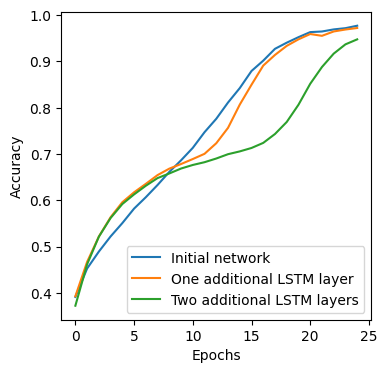

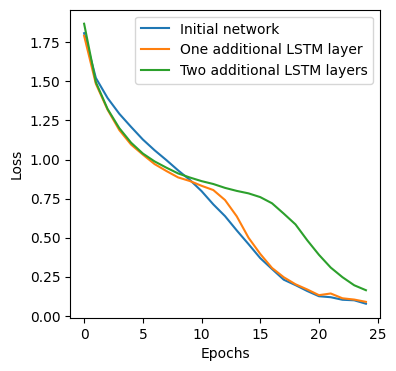

In [10]:
plt.figure(figsize=(4,4))
plt.plot(init_results_acc, label="Initial network")
plt.plot(one_results_acc, label="One additional LSTM layer")
plt.plot(two_results_acc, label="Two additional LSTM layers")

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('img2text_acc.png', bbox_inches="tight")
plt.show()

plt.figure(figsize=(4,4))
plt.plot(init_results_loss, label="Initial network")
plt.plot(one_results_loss, label="One additional LSTM layer")
plt.plot(two_results_loss, label="Two additional LSTM layers")

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('imgttext_loss.png', bbox_inches="tight")
plt.show()

---
---

## III. Text to image RNN Model

Hint: to make this model work really well you could use deconvolutional layers in your decoder (you might need to look up ***Conv2DTranspose*** layer). However, regular vector-based decoder will work as well.

The goal here is to use **X_text** as inputs and **y_img** as outputs.

In [ ]:
# import numpy as np

# unique_values = np.unique(y_img)
# print(unique_values)

[0.         0.00392157 0.00784314 0.01176471 0.01568627 0.01960784
 0.02352941 0.02745098 0.03137255 0.03529412 0.03921569 0.04313725
 0.04705882 0.05098039 0.05490196 0.05882353 0.0627451  0.06666667
 0.07058824 0.0745098  0.07843137 0.08235294 0.08627451 0.09019608
 0.09411765 0.09803922 0.10196078 0.10588235 0.10980392 0.11372549
 0.11764706 0.12156863 0.1254902  0.12941176 0.13333333 0.1372549
 0.14117647 0.14509804 0.14901961 0.15294118 0.15686275 0.16078431
 0.16470588 0.16862745 0.17254902 0.17647059 0.18039216 0.18431373
 0.18823529 0.19215686 0.19607843 0.2        0.20392157 0.20784314
 0.21176471 0.21568627 0.21960784 0.22352941 0.22745098 0.23137255
 0.23529412 0.23921569 0.24313725 0.24705882 0.25098039 0.25490196
 0.25882353 0.2627451  0.26666667 0.27058824 0.2745098  0.27843137
 0.28235294 0.28627451 0.29019608 0.29411765 0.29803922 0.30196078
 0.30588235 0.30980392 0.31372549 0.31764706 0.32156863 0.3254902
 0.32941176 0.33333333 0.3372549  0.34117647 0.34509804 0.349019

In [ ]:
# univalues = np.unique(X_text_onehot)
# print(univalues)

[0. 1.]


In [ ]:
y_img.shape[1:][1]

28

# Initial Model: Text-to-image

In [ ]:
text2image = Sequential()

# Encoder
text2image.add(LSTM(512, input_shape=(max_query_length, len(unique_characters))))
text2image.add(LayerNormalization())

# Repeat the vector for decoding
text2image.add(RepeatVector(max_answer_length))

# Decoder
text2image.add(LSTM(512, return_sequences=True))
text2image.add(LayerNormalization())

# TimeDistributed layer for Dense
text2image.add(TimeDistributed(Dense((28 * 28), activation='softmax')))
text2image.add(LayerNormalization())

text2image.add(Reshape((max_answer_length, 28, 28)))

# Conv2DTranspose layers
text2image.add(Conv2DTranspose(128, (3, 3), padding='same', activation='relu'))
text2image.add(BatchNormalization())

text2image.add(Conv2DTranspose(64, (3, 3), padding='same', activation='relu'))
text2image.add(BatchNormalization())

text2image.add(Conv2DTranspose(28, (3, 3), padding='same', activation='sigmoid'))  # black and white images




text2image.compile(loss='mean_squared_error', optimizer='adam', metrics=['mse', 'mean_absolute_error'])

X_text_train, X_text_test, y_img_train, y_img_test = train_test_split(X_text_onehot, y_img, test_size=0.25, random_state=0)

text_to_img_history = text2image.fit(X_text_train, y_img_train, epochs=20, batch_size=28, validation_data=(X_text_test, y_img_test))

text_to_img_results = text2image.evaluate(X_text_test, y_img_test)
print("Test loss, test mse, test mae:", text_to_img_results)


Epoch 1/20
536/536 [==============================] - 33s 31ms/step - loss: 0.0555 - mse: 0.0555 - mean_absolute_error: 0.1306 - val_loss: 0.0486 - val_mse: 0.0486 - val_mean_absolute_error: 0.1088
Epoch 2/20
536/536 [==============================] - 12s 22ms/step - loss: 0.0486 - mse: 0.0486 - mean_absolute_error: 0.1120 - val_loss: 0.0478 - val_mse: 0.0478 - val_mean_absolute_error: 0.1072
Epoch 3/20
536/536 [==============================] - 9s 17ms/step - loss: 0.0478 - mse: 0.0478 - mean_absolute_error: 0.1095 - val_loss: 0.0479 - val_mse: 0.0479 - val_mean_absolute_error: 0.1089
Epoch 4/20
536/536 [==============================] - 9s 17ms/step - loss: 0.0472 - mse: 0.0472 - mean_absolute_error: 0.1080 - val_loss: 0.0468 - val_mse: 0.0468 - val_mean_absolute_error: 0.1073
Epoch 5/20
536/536 [==============================] - 12s 23ms/step - loss: 0.0468 - mse: 0.0468 - mean_absolute_error: 0.1068 - val_loss: 0.0462 - val_mse: 0.0462 - val_mean_absolute_error: 0.1042
Epoch 6/20
5

In [ ]:
# fuction for visualizing generated images 
def generate_images_from_text(model, text_query):
    text_query_onehot = encode_labels([text_query])
    predicted_images = model.predict(text_query_onehot)
    return predicted_images.squeeze()


1/1 [==============================] - 1s 877ms/step


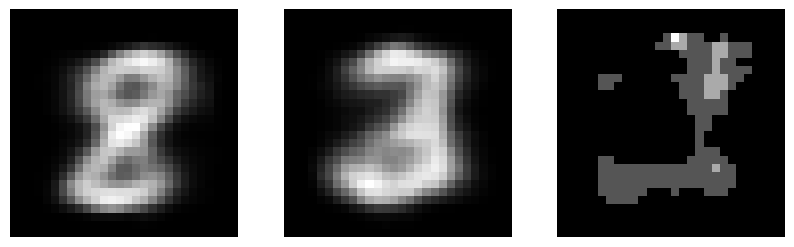

In [ ]:
text_query1 = '24+59'
generated_images = generate_images_from_text(text2image, text_query1)

generated_images = generated_images * 255.0


plt.figure(figsize=(10, 5))
for i in range(generated_images.shape[0]):
    plt.subplot(1, generated_images.shape[0], i + 1)
    plt.imshow(generated_images[i].astype(int), cmap='gray')  
    plt.axis('off')
plt.show()

1/1 [==============================] - 0s 21ms/step


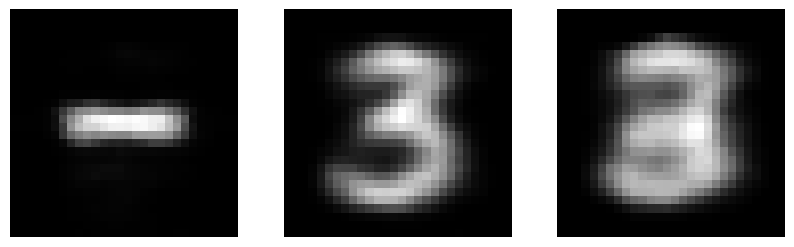

In [ ]:
text_query2 = '26-59'
generated_images1 = generate_images_from_text(text2image, text_query2)

generated_images1 = generated_images1 * 255.0


plt.figure(figsize=(10, 5))
for i in range(generated_images1.shape[0]):
    plt.subplot(1, generated_images1.shape[0], i + 1)
    plt.imshow(generated_images1[i].astype(int), cmap='gray')  
    plt.axis('off')
plt.show()

1/1 [==============================] - 0s 29ms/step


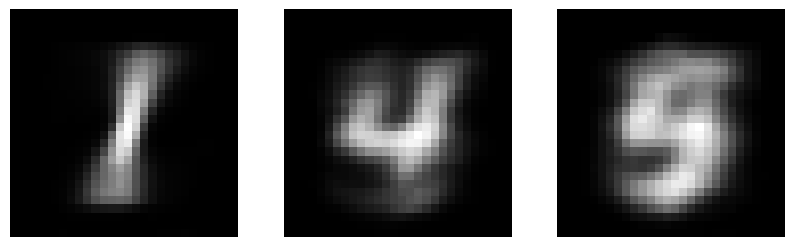

In [ ]:
text_query3 = '89+56'
generated_images2 = generate_images_from_text(text2image, text_query3)

generated_images2 = generated_images2 * 255.0


plt.figure(figsize=(10, 5))
for i in range(generated_images2.shape[0]):
    plt.subplot(1, generated_images2.shape[0], i + 1)
    plt.imshow(generated_images2[i].astype(int), cmap='gray')  
    plt.axis('off')
plt.show()

# Add additional LSTM layers to your encoder networks - Text-to-image network

## Adding one extra LSTM layer in the encoder - 512 units 

In [ ]:
text2image2 = Sequential()

# First LSTM layer with return_sequences=True
text2image2.add(LSTM(512, input_shape=(max_query_length, len(unique_characters)), return_sequences=True))
text2image2.add(LayerNormalization())

# Second LSTM layer
text2image2.add(LSTM(512, return_sequences=False))
text2image2.add(LayerNormalization())

# Repeat the vector for decoding
text2image2.add(RepeatVector(max_answer_length))

# The rest of your model remains the same
text2image2.add(LSTM(512, return_sequences=True))
text2image2.add(LayerNormalization())

text2image2.add(TimeDistributed(Dense((28 * 28), activation='softmax')))
text2image2.add(LayerNormalization())

text2image2.add(Reshape((max_answer_length, 28, 28)))

text2image2.add(Conv2DTranspose(128, (3, 3), padding='same', activation='relu'))
text2image2.add(BatchNormalization())

text2image2.add(Conv2DTranspose(64, (3, 3), padding='same', activation='relu'))
text2image2.add(BatchNormalization())

text2image2.add(Conv2DTranspose(28, (3, 3), padding='same', activation='sigmoid'))

text2image2.compile(loss='mean_squared_error', optimizer='adam', metrics=['mse', 'mean_absolute_error'])



X_text_train, X_text_test, y_img_train, y_img_test = train_test_split(X_text_onehot, y_img, test_size=0.25, random_state=0)

text_to_img_history2 = text2image2.fit(X_text_train, y_img_train, epochs=20, batch_size=28, validation_data=(X_text_test, y_img_test))

text_to_img_results2 = text2image2.evaluate(X_text_test, y_img_test)
print("Test loss, test mse, test mae:", text_to_img_results2)


Epoch 1/20
536/536 [==============================] - 21s 22ms/step - loss: 0.0557 - mse: 0.0557 - mean_absolute_error: 0.1313 - val_loss: 0.0487 - val_mse: 0.0487 - val_mean_absolute_error: 0.1074
Epoch 2/20
536/536 [==============================] - 9s 16ms/step - loss: 0.0484 - mse: 0.0484 - mean_absolute_error: 0.1115 - val_loss: 0.0476 - val_mse: 0.0476 - val_mean_absolute_error: 0.1065
Epoch 3/20
536/536 [==============================] - 10s 18ms/step - loss: 0.0473 - mse: 0.0473 - mean_absolute_error: 0.1085 - val_loss: 0.0468 - val_mse: 0.0468 - val_mean_absolute_error: 0.1055
Epoch 4/20
536/536 [==============================] - 9s 18ms/step - loss: 0.0467 - mse: 0.0467 - mean_absolute_error: 0.1067 - val_loss: 0.0459 - val_mse: 0.0459 - val_mean_absolute_error: 0.1051
Epoch 5/20
536/536 [==============================] - 8s 15ms/step - loss: 0.0460 - mse: 0.0460 - mean_absolute_error: 0.1050 - val_loss: 0.0459 - val_mse: 0.0459 - val_mean_absolute_error: 0.1040
Epoch 6/20
53

1/1 [==============================] - 3s 3s/step


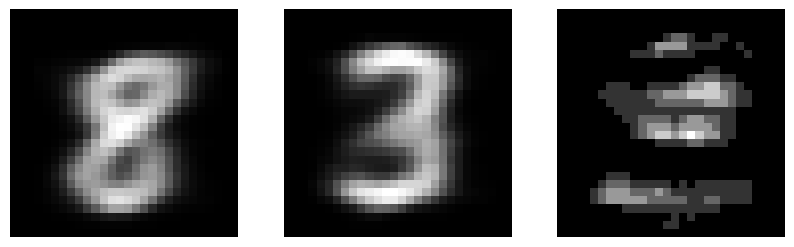

In [ ]:
text_query1 = '24+59'
generated_images3 = generate_images_from_text(text2image2, text_query1)

generated_images3 = generated_images3 * 255.0


plt.figure(figsize=(10, 5))
for i in range(generated_images3.shape[0]):
    plt.subplot(1, generated_images3.shape[0], i + 1)
    plt.imshow(generated_images3[i].astype(int), cmap='gray') 
    plt.axis('off')
plt.show()

1/1 [==============================] - 0s 36ms/step


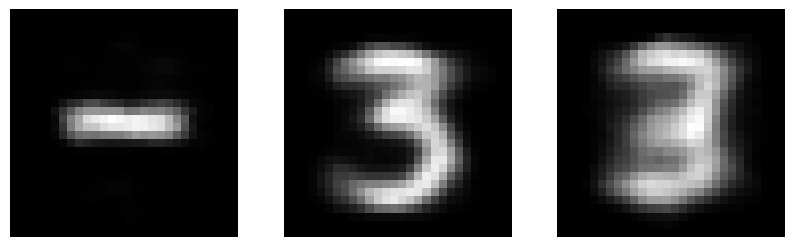

In [ ]:
text_query2 = '26-59'
generated_images4 = generate_images_from_text(text2image2, text_query2)

generated_images4 = generated_images4 * 255.0


plt.figure(figsize=(10, 5))
for i in range(generated_images4.shape[0]):
    plt.subplot(1, generated_images4.shape[0], i + 1)
    plt.imshow(generated_images4[i].astype(int), cmap='gray') 
    plt.axis('off')
plt.show()

1/1 [==============================] - 0s 43ms/step


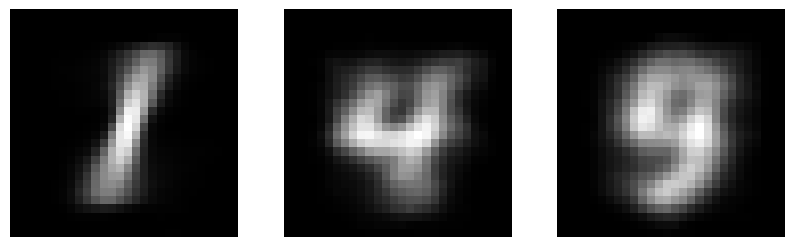

In [ ]:
text_query3 = '89+56'
generated_images5 = generate_images_from_text(text2image2, text_query3)

generated_images5= generated_images5 * 255.0


plt.figure(figsize=(10, 5))
for i in range(generated_images5.shape[0]):
    plt.subplot(1, generated_images5.shape[0], i + 1)
    plt.imshow(generated_images5[i].astype(int), cmap='gray')  
    plt.axis('off')
plt.show()

## Adding one extra LSTM layer in the encoder - 256 units

In [ ]:
text2image3 = Sequential()

# First LSTM layer with return_sequences=True
text2image3.add(LSTM(512, input_shape=(max_query_length, len(unique_characters)), return_sequences=True))
text2image3.add(LayerNormalization())

# second LSTM layer with return_sequences=False - 256 units
text2image3.add(LSTM(256, return_sequences=False))
text2image3.add(LayerNormalization())

# Decoder
text2image3.add(RepeatVector(max_answer_length))

text2image3.add(LSTM(512, return_sequences=True))
text2image3.add(LayerNormalization())

text2image3.add(TimeDistributed(Dense((28 * 28), activation='softmax')))
text2image3.add(LayerNormalization())

text2image3.add(Reshape((max_answer_length, 28, 28)))

text2image3.add(Conv2DTranspose(128, (3, 3), padding='same', activation='relu'))
text2image3.add(BatchNormalization())

text2image3.add(Conv2DTranspose(64, (3, 3), padding='same', activation='relu'))
text2image3.add(BatchNormalization())

text2image3.add(Conv2DTranspose(28, (3, 3), padding='same', activation='sigmoid'))

text2image3.compile(loss='mean_squared_error', optimizer='adam', metrics=['mse', 'mean_absolute_error'])



X_text_train, X_text_test, y_img_train, y_img_test = train_test_split(X_text_onehot, y_img, test_size=0.25, random_state=0)


text_to_img_history3 = text2image3.fit(X_text_train, y_img_train, epochs=20, batch_size=28,
                                       validation_data=(X_text_test, y_img_test))

text_to_img_results3 = text2image3.evaluate(X_text_test, y_img_test)
print("Test loss, test mse, test mae:", text_to_img_results3)


Epoch 1/20
536/536 [==============================] - 91s 157ms/step - loss: 0.0552 - mse: 0.0552 - mean_absolute_error: 0.1301 - val_loss: 0.0489 - val_mse: 0.0489 - val_mean_absolute_error: 0.1093
Epoch 2/20
536/536 [==============================] - 85s 159ms/step - loss: 0.0480 - mse: 0.0480 - mean_absolute_error: 0.1107 - val_loss: 0.0475 - val_mse: 0.0475 - val_mean_absolute_error: 0.1059
Epoch 3/20
536/536 [==============================] - 89s 165ms/step - loss: 0.0471 - mse: 0.0471 - mean_absolute_error: 0.1080 - val_loss: 0.0468 - val_mse: 0.0468 - val_mean_absolute_error: 0.1041
Epoch 4/20
536/536 [==============================] - 90s 169ms/step - loss: 0.0464 - mse: 0.0464 - mean_absolute_error: 0.1063 - val_loss: 0.0461 - val_mse: 0.0461 - val_mean_absolute_error: 0.1050
Epoch 5/20
536/536 [==============================] - 89s 166ms/step - loss: 0.0457 - mse: 0.0457 - mean_absolute_error: 0.1046 - val_loss: 0.0455 - val_mse: 0.0455 - val_mean_absolute_error: 0.1027
Epoch

1/1 [==============================] - 3s 3s/step


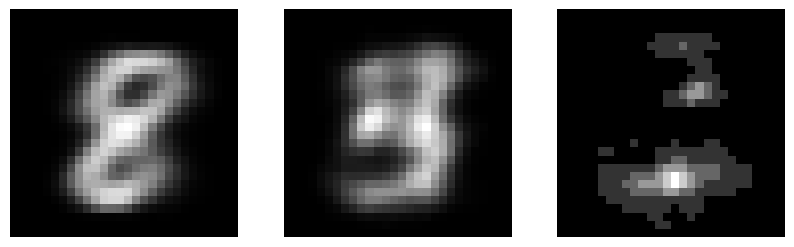

In [ ]:
text_query1 = '24+59'
generated_images6 = generate_images_from_text(text2image3, text_query1)

generated_images6 = generated_images6 * 255.0

plt.figure(figsize=(10, 5))
for i in range(generated_images6.shape[0]):
    plt.subplot(1, generated_images6.shape[0], i + 1)
    plt.imshow(generated_images6[i].astype(int), cmap='gray')
    plt.axis('off')
plt.show()

1/1 [==============================] - 0s 25ms/step


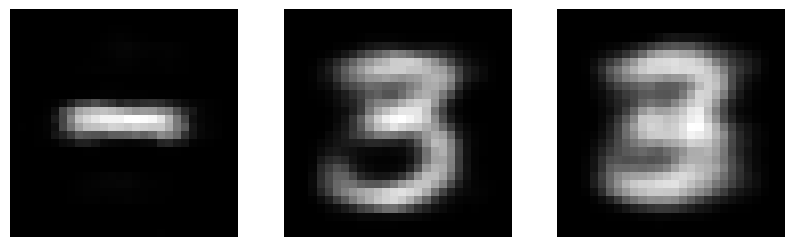

In [ ]:
text_query2 = '26-59'
generated_images7 = generate_images_from_text(text2image3, text_query2)

generated_images7 = generated_images7 * 255.0

plt.figure(figsize=(10, 5))
for i in range(generated_images7.shape[0]):
    plt.subplot(1, generated_images7.shape[0], i + 1)
    plt.imshow(generated_images7[i].astype(int), cmap='gray')
    plt.axis('off')
plt.show()

1/1 [==============================] - 0s 32ms/step


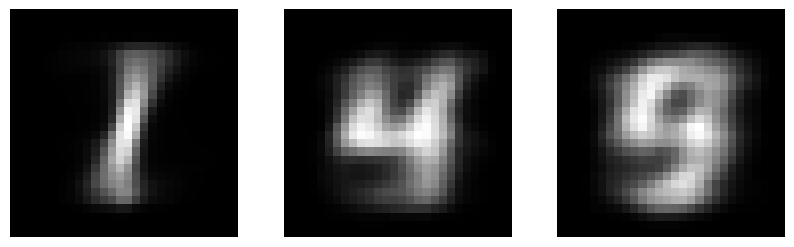

In [ ]:
text_query3 = '89+56'
generated_images8 = generate_images_from_text(text2image3, text_query3)

generated_images8 = generated_images8 * 255.0

plt.figure(figsize=(10, 5))
for i in range(generated_images8.shape[0]):
    plt.subplot(1, generated_images8.shape[0], i + 1)
    plt.imshow(generated_images8[i].astype(int), cmap='gray')
    plt.axis('off')
plt.show()

## Adding two extra LSTM layer in the encoder - both 512 units

In [ ]:
text2image4 = Sequential()

# First LSTM layer with return_sequences=True
text2image4.add(LSTM(512, input_shape=(max_query_length, len(unique_characters)), return_sequences=True))
text2image4.add(LayerNormalization())

# Second LSTM layer
text2image4.add(LSTM(512, return_sequences=True))
text2image4.add(LayerNormalization())

text2image4.add(LSTM(512, return_sequences=False))
text2image4.add(LayerNormalization())

# Repeat the vector for decoding
text2image4.add(RepeatVector(max_answer_length))

# The rest of the model remains the same
text2image4.add(LSTM(512, return_sequences=True))
text2image4.add(LayerNormalization())

text2image4.add(TimeDistributed(Dense((28 * 28), activation='softmax')))
text2image4.add(LayerNormalization())

text2image4.add(Reshape((max_answer_length, 28, 28)))

text2image4.add(Conv2DTranspose(128, (3, 3), padding='same', activation='relu'))
text2image4.add(BatchNormalization())

text2image4.add(Conv2DTranspose(64, (3, 3), padding='same', activation='relu'))
text2image4.add(BatchNormalization())

text2image4.add(Conv2DTranspose(28, (3, 3), padding='same', activation='sigmoid'))


text2image4.compile(loss='mean_squared_error', optimizer='adam', metrics=['mse', 'mean_absolute_error'])


X_text_train, X_text_test, y_img_train, y_img_test = train_test_split(X_text_onehot, y_img, test_size=0.25, random_state=0)

text_to_img_history4 = text2image4.fit(X_text_train, y_img_train, epochs=20, batch_size=28, validation_data=(X_text_test, y_img_test))

text_to_img_results4 = text2image4.evaluate(X_text_test, y_img_test)
print("Test loss, test mse, test mae:", text_to_img_results4)


Epoch 1/20
536/536 [==============================] - 26s 23ms/step - loss: 0.0554 - mse: 0.0554 - mean_absolute_error: 0.1305 - val_loss: 0.0492 - val_mse: 0.0492 - val_mean_absolute_error: 0.1085
Epoch 2/20
536/536 [==============================] - 11s 20ms/step - loss: 0.0480 - mse: 0.0480 - mean_absolute_error: 0.1107 - val_loss: 0.0476 - val_mse: 0.0476 - val_mean_absolute_error: 0.1071
Epoch 3/20
536/536 [==============================] - 10s 18ms/step - loss: 0.0471 - mse: 0.0471 - mean_absolute_error: 0.1080 - val_loss: 0.0464 - val_mse: 0.0464 - val_mean_absolute_error: 0.1054
Epoch 4/20
536/536 [==============================] - 9s 17ms/step - loss: 0.0464 - mse: 0.0464 - mean_absolute_error: 0.1062 - val_loss: 0.0462 - val_mse: 0.0462 - val_mean_absolute_error: 0.1044
Epoch 5/20
536/536 [==============================] - 15s 28ms/step - loss: 0.0457 - mse: 0.0457 - mean_absolute_error: 0.1047 - val_loss: 0.0453 - val_mse: 0.0453 - val_mean_absolute_error: 0.1025
Epoch 6/20


1/1 [==============================] - 1s 1s/step


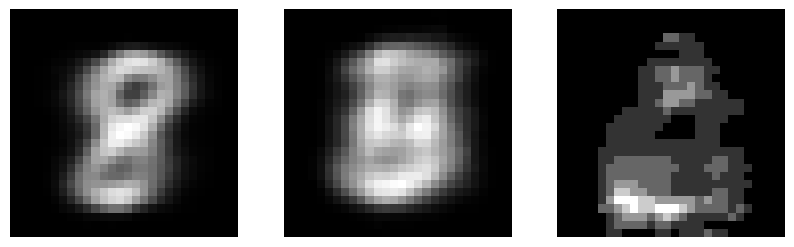

In [ ]:
text_query1 = '24+59'
generated_images9 = generate_images_from_text(text2image4, text_query1)

generated_images9 = generated_images9 * 255.0

plt.figure(figsize=(10, 5))
for i in range(generated_images9.shape[0]):
    plt.subplot(1, generated_images9.shape[0], i + 1)
    plt.imshow(generated_images9[i].astype(int), cmap='gray')
    plt.axis('off')
plt.show()

1/1 [==============================] - 0s 30ms/step


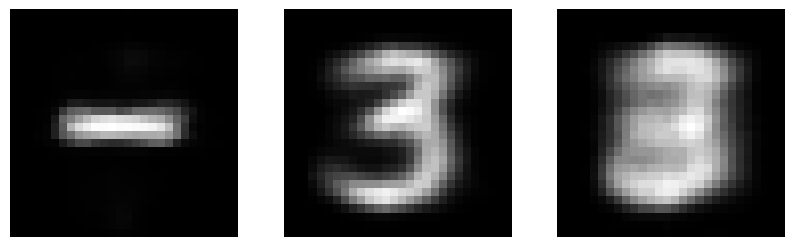

In [ ]:
text_query2 = '26-59'
generated_images10 = generate_images_from_text(text2image4, text_query2)

generated_images10 = generated_images10 * 255.0

plt.figure(figsize=(10, 5))
for i in range(generated_images10.shape[0]):
    plt.subplot(1, generated_images10.shape[0], i + 1)
    plt.imshow(generated_images10[i].astype(int), cmap='gray')
    plt.axis('off')
plt.show()

1/1 [==============================] - 0s 30ms/step


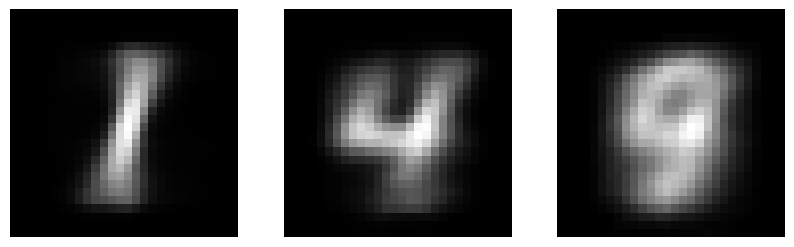

In [ ]:
text_query3 = '89+56'
generated_images11 = generate_images_from_text(text2image4, text_query3)

generated_images11 = generated_images11 * 255.0

plt.figure(figsize=(10, 5))
for i in range(generated_images11.shape[0]):
    plt.subplot(1, generated_images11.shape[0], i + 1)
    plt.imshow(generated_images11[i].astype(int), cmap='gray')
    plt.axis('off')
plt.show()

## Adding two extra LSTM layer in the encoder - 256 and 128 units

In [ ]:
text2image5 = Sequential()

# First LSTM layer with return_sequences=True
text2image5.add(LSTM(512, input_shape=(max_query_length, len(unique_characters)), return_sequences=True))
text2image5.add(LayerNormalization())

# Second LSTM layer
text2image5.add(LSTM(256, return_sequences=True))
text2image5.add(LayerNormalization())

text2image5.add(LSTM(128, return_sequences=False))
text2image5.add(LayerNormalization())

# Repeat the vector for decoding
text2image5.add(RepeatVector(max_answer_length))

# The rest of the model remains the same
text2image5.add(LSTM(512, return_sequences=True))
text2image5.add(LayerNormalization())

text2image5.add(TimeDistributed(Dense((28 * 28), activation='softmax')))
text2image5.add(LayerNormalization())

text2image5.add(Reshape((max_answer_length, 28, 28)))

text2image5.add(Conv2DTranspose(128, (3, 3), padding='same', activation='relu'))
text2image5.add(BatchNormalization())

text2image5.add(Conv2DTranspose(64, (3, 3), padding='same', activation='relu'))
text2image5.add(BatchNormalization())

text2image5.add(Conv2DTranspose(28, (3, 3), padding='same', activation='sigmoid'))


text2image5.compile(loss='mean_squared_error', optimizer='adam', metrics=['mse', 'mean_absolute_error'])


X_text_train, X_text_test, y_img_train, y_img_test = train_test_split(X_text_onehot, y_img, test_size=0.25, random_state=0)

text_to_img_history5 = text2image5.fit(X_text_train, y_img_train, epochs=20, batch_size=28, validation_data=(X_text_test, y_img_test))

text_to_img_results5 = text2image5.evaluate(X_text_test, y_img_test)
print("Test loss, test mse, test mae:", text_to_img_results5)


Epoch 1/20
536/536 [==============================] - 154s 268ms/step - loss: 0.0556 - mse: 0.0556 - mean_absolute_error: 0.1308 - val_loss: 0.0495 - val_mse: 0.0495 - val_mean_absolute_error: 0.1093
Epoch 2/20
536/536 [==============================] - 139s 259ms/step - loss: 0.0481 - mse: 0.0481 - mean_absolute_error: 0.1109 - val_loss: 0.0479 - val_mse: 0.0479 - val_mean_absolute_error: 0.1097
Epoch 3/20
536/536 [==============================] - 129s 241ms/step - loss: 0.0471 - mse: 0.0471 - mean_absolute_error: 0.1081 - val_loss: 0.0469 - val_mse: 0.0469 - val_mean_absolute_error: 0.1046
Epoch 4/20
536/536 [==============================] - 130s 242ms/step - loss: 0.0464 - mse: 0.0464 - mean_absolute_error: 0.1062 - val_loss: 0.0458 - val_mse: 0.0458 - val_mean_absolute_error: 0.1032
Epoch 5/20
536/536 [==============================] - 131s 245ms/step - loss: 0.0455 - mse: 0.0455 - mean_absolute_error: 0.1042 - val_loss: 0.0459 - val_mse: 0.0459 - val_mean_absolute_error: 0.1036


1/1 [==============================] - 2s 2s/step


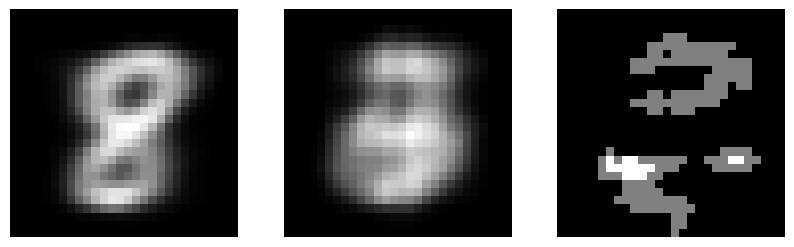

In [ ]:
text_query1 = '24+59'
generated_images12 = generate_images_from_text(text2image5, text_query1)

generated_images12 = generated_images12 * 255.0

plt.figure(figsize=(10, 5))
for i in range(generated_images12.shape[0]):
    plt.subplot(1, generated_images12.shape[0], i + 1)
    plt.imshow(generated_images12[i].astype(int), cmap='gray')
    plt.axis('off')
plt.show()

1/1 [==============================] - 0s 44ms/step


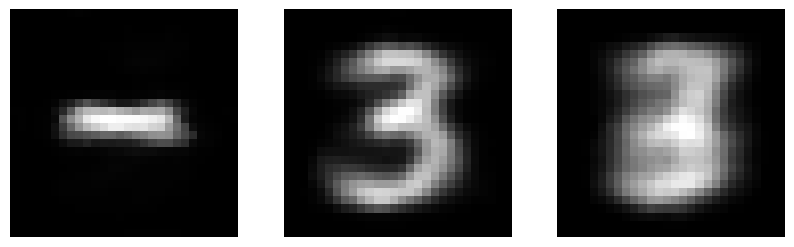

In [ ]:
text_query2 = '26-59'
generated_images13 = generate_images_from_text(text2image5, text_query2)

generated_images13 = generated_images13 * 255.0

plt.figure(figsize=(10, 5))
for i in range(generated_images13.shape[0]):
    plt.subplot(1, generated_images13.shape[0], i + 1)
    plt.imshow(generated_images13[i].astype(int), cmap='gray')
    plt.axis('off')
plt.show()

1/1 [==============================] - 0s 30ms/step


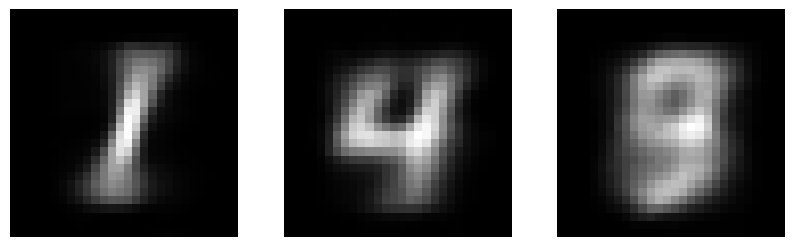

In [ ]:
text_query3 = '89+56'
generated_images14 = generate_images_from_text(text2image5, text_query3)

generated_images14 = generated_images14 * 255.0

plt.figure(figsize=(10, 5))
for i in range(generated_images14.shape[0]):
    plt.subplot(1, generated_images14.shape[0], i + 1)
    plt.imshow(generated_images14[i].astype(int), cmap='gray')
    plt.axis('off')
plt.show()

## More epoch (= 50) for image appearance improvement

### Basic Model

In [ ]:
text2image_50 = Sequential()

# Encoder
text2image_50.add(LSTM(512, input_shape=(max_query_length, len(unique_characters))))
text2image_50.add(LayerNormalization())

# Repeat the vector for decoding
text2image_50.add(RepeatVector(max_answer_length))

# Decoder
text2image_50.add(LSTM(512, return_sequences=True))
text2image_50.add(LayerNormalization())

# TimeDistributed layer for Dense
text2image_50.add(TimeDistributed(Dense((28 * 28), activation='softmax')))
text2image_50.add(LayerNormalization())

text2image_50.add(Reshape((max_answer_length, 28, 28)))

# Conv2DTranspose layers
text2image_50.add(Conv2DTranspose(128, (3, 3), padding='same', activation='relu'))
text2image_50.add(BatchNormalization())

text2image_50.add(Conv2DTranspose(64, (3, 3), padding='same', activation='relu'))
text2image_50.add(BatchNormalization())

text2image_50.add(Conv2DTranspose(28, (3, 3), padding='same', activation='sigmoid'))  # black and white images


text2image_50.compile(loss='mean_squared_error', optimizer='adam', metrics=['mse', 'mean_absolute_error'])


X_text_train, X_text_test, y_img_train, y_img_test = train_test_split(X_text_onehot, y_img, test_size=0.25, random_state=0)


text_to_img_history_50 = text2image_50.fit(X_text_train, y_img_train, epochs=50, batch_size=28, validation_data=(X_text_test, y_img_test))

text_to_img_results_50 = text2image_50.evaluate(X_text_test, y_img_test)
print("Test loss, test mse, test mae:", text_to_img_results_50)


Epoch 1/50
536/536 [==============================] - 14s 16ms/step - loss: 0.0552 - mse: 0.0552 - mean_absolute_error: 0.1299 - val_loss: 0.0485 - val_mse: 0.0485 - val_mean_absolute_error: 0.1102
Epoch 2/50
536/536 [==============================] - 6s 11ms/step - loss: 0.0483 - mse: 0.0483 - mean_absolute_error: 0.1113 - val_loss: 0.0481 - val_mse: 0.0481 - val_mean_absolute_error: 0.1088
Epoch 3/50
536/536 [==============================] - 7s 13ms/step - loss: 0.0475 - mse: 0.0475 - mean_absolute_error: 0.1087 - val_loss: 0.0476 - val_mse: 0.0476 - val_mean_absolute_error: 0.1055
Epoch 4/50
536/536 [==============================] - 6s 11ms/step - loss: 0.0470 - mse: 0.0470 - mean_absolute_error: 0.1074 - val_loss: 0.0462 - val_mse: 0.0462 - val_mean_absolute_error: 0.1060
Epoch 5/50
536/536 [==============================] - 9s 17ms/step - loss: 0.0464 - mse: 0.0464 - mean_absolute_error: 0.1060 - val_loss: 0.0460 - val_mse: 0.0460 - val_mean_absolute_error: 0.1054
Epoch 6/50
536

1/1 [==============================] - 1s 796ms/step


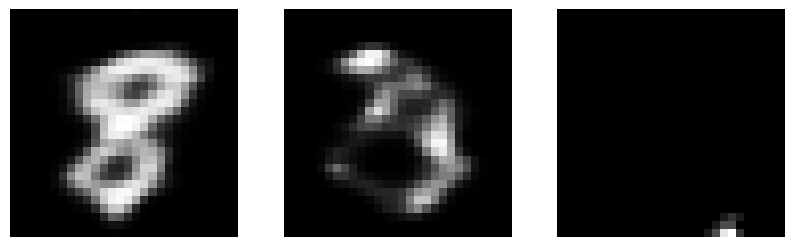

In [ ]:
text_query1 = '24+59'
generated_images15 = generate_images_from_text(text2image_50, text_query1)


generated_images15 = generated_images15 * 255.0


plt.figure(figsize=(10, 5))
for i in range(generated_images15.shape[0]):
    plt.subplot(1, generated_images15.shape[0], i + 1)
    plt.imshow(generated_images15[i].astype(int), cmap='gray')
    plt.axis('off')
plt.show()


1/1 [==============================] - 0s 28ms/step


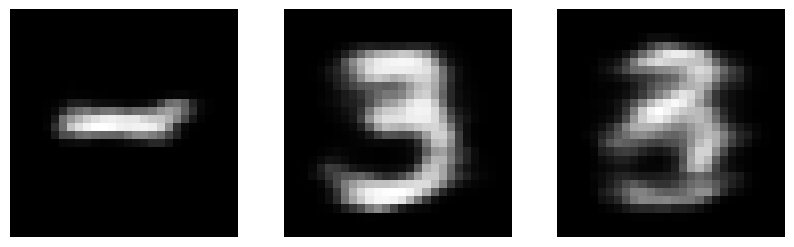

In [ ]:
text_query2 = '26-59'

generated_images16 = generate_images_from_text(text2image_50, text_query2)

generated_images16 = generated_images16 * 255.0

plt.figure(figsize=(10, 5))
for i in range(generated_images16.shape[0]):
    plt.subplot(1, generated_images16.shape[0], i + 1)
    plt.imshow(generated_images16[i].astype(int), cmap='gray')  # Adjust cmap if needed
    plt.axis('off')
plt.show()

1/1 [==============================] - 0s 30ms/step


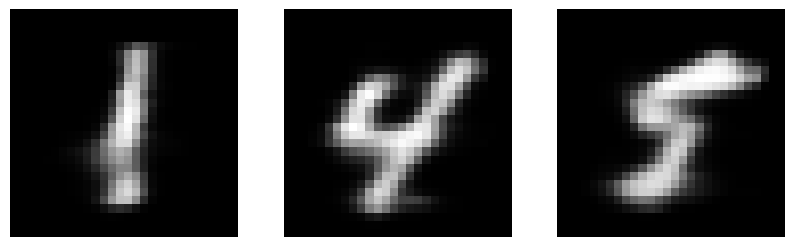

In [ ]:
text_query3 = '89+56'
generated_images17 = generate_images_from_text(text2image_50, text_query3)

generated_images17 = generated_images17 * 255.0

plt.figure(figsize=(10, 5))
for i in range(generated_images17.shape[0]):
    plt.subplot(1, generated_images17.shape[0], i + 1)
    plt.imshow(generated_images17[i].astype(int), cmap='gray')
    plt.axis('off')
plt.show()

### One extra LSTM layer - 256 units - 50 epoch

In [ ]:
text2image3_50 = Sequential()

# First LSTM layer with return_sequences=True
text2image3_50.add(LSTM(512, input_shape=(max_query_length, len(unique_characters)), return_sequences=True))
text2image3_50.add(LayerNormalization())

# Second LSTM layer
text2image3_50.add(LSTM(256, return_sequences=False))
text2image3_50.add(LayerNormalization())

# Repeat the vector for decoding
text2image3_50.add(RepeatVector(max_answer_length))

# The rest of the model remains the same
text2image3_50.add(LSTM(512, return_sequences=True))
text2image3_50.add(LayerNormalization())

text2image3_50.add(TimeDistributed(Dense((28 * 28), activation='softmax')))
text2image3_50.add(LayerNormalization())

text2image3_50.add(Reshape((max_answer_length, 28, 28)))

text2image3_50.add(Conv2DTranspose(128, (3, 3), padding='same', activation='relu'))
text2image3_50.add(BatchNormalization())

text2image3_50.add(Conv2DTranspose(64, (3, 3), padding='same', activation='relu'))
text2image3_50.add(BatchNormalization())

text2image3_50.add(Conv2DTranspose(28, (3, 3), padding='same', activation='sigmoid'))


text2image3_50.compile(loss='mean_squared_error', optimizer='adam', metrics=['mse', 'mean_absolute_error'])


X_text_train, X_text_test, y_img_train, y_img_test = train_test_split(X_text_onehot, y_img, test_size=0.25, random_state=0)

text_to_img_history3_50 = text2image3_50.fit(X_text_train, y_img_train, epochs=50, batch_size=28, validation_data=(X_text_test, y_img_test))

text_to_img_results3_50 = text2image3_50.evaluate(X_text_test, y_img_test)
print("Test loss, test mse, test mae:", text_to_img_results3_50)

Epoch 1/50
536/536 [==============================] - 17s 16ms/step - loss: 0.0556 - mse: 0.0556 - mean_absolute_error: 0.1308 - val_loss: 0.0486 - val_mse: 0.0486 - val_mean_absolute_error: 0.1105
Epoch 2/50
536/536 [==============================] - 8s 16ms/step - loss: 0.0481 - mse: 0.0481 - mean_absolute_error: 0.1111 - val_loss: 0.0478 - val_mse: 0.0478 - val_mean_absolute_error: 0.1069
Epoch 3/50
536/536 [==============================] - 7s 13ms/step - loss: 0.0472 - mse: 0.0472 - mean_absolute_error: 0.1082 - val_loss: 0.0471 - val_mse: 0.0471 - val_mean_absolute_error: 0.1055
Epoch 4/50
536/536 [==============================] - 8s 15ms/step - loss: 0.0464 - mse: 0.0464 - mean_absolute_error: 0.1063 - val_loss: 0.0459 - val_mse: 0.0459 - val_mean_absolute_error: 0.1041
Epoch 5/50
536/536 [==============================] - 8s 15ms/step - loss: 0.0459 - mse: 0.0459 - mean_absolute_error: 0.1049 - val_loss: 0.0454 - val_mse: 0.0454 - val_mean_absolute_error: 0.1022
Epoch 6/50
536

1/1 [==============================] - 1s 1s/step


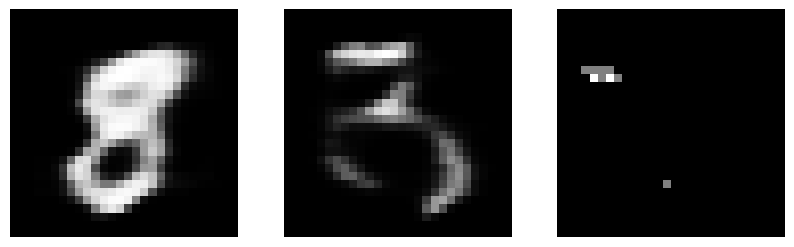

In [ ]:
text_query1 = '24+59'
generated_images18 = generate_images_from_text(text2image3_50, text_query1)

generated_images18 = generated_images18 * 255.0

plt.figure(figsize=(10, 5))
for i in range(generated_images18.shape[0]):
    plt.subplot(1, generated_images18.shape[0], i + 1)
    plt.imshow(generated_images18[i].astype(int), cmap='gray')
    plt.axis('off')
plt.show()

1/1 [==============================] - 0s 27ms/step


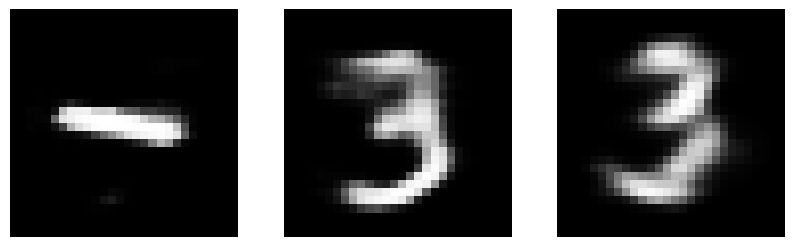

In [ ]:
text_query2 = '26-59'
generated_images19 = generate_images_from_text(text2image3_50, text_query2)

generated_images19 = generated_images19 * 255.0

plt.figure(figsize=(10, 5))
for i in range(generated_images19.shape[0]):
    plt.subplot(1, generated_images19.shape[0], i + 1)
    plt.imshow(generated_images19[i].astype(int), cmap='gray')
    plt.axis('off')
plt.show()

1/1 [==============================] - 0s 26ms/step


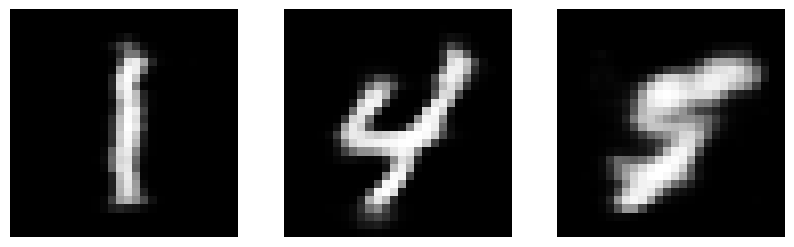

In [ ]:
text_query3 = '89+56'
generated_images20 = generate_images_from_text(text2image3_50, text_query3)

generated_images20 = generated_images20 * 255.0

plt.figure(figsize=(10, 5))
for i in range(generated_images20.shape[0]):
    plt.subplot(1, generated_images20.shape[0], i + 1)
    plt.imshow(generated_images20[i].astype(int), cmap='gray')
    plt.axis('off')
plt.show()

### Two extra LSTM layers - both 512 units - 50 epoch

In [ ]:
text2image4_50 = Sequential()

# First LSTM layer with return_sequences=True
text2image4_50.add(LSTM(512, input_shape=(max_query_length, len(unique_characters)), return_sequences=True))
text2image4_50.add(LayerNormalization())

# Second LSTM layer
text2image4_50.add(LSTM(512, return_sequences=True))
text2image4_50.add(LayerNormalization())

text2image4_50.add(LSTM(512, return_sequences=False))
text2image4_50.add(LayerNormalization())

# Repeat the vector for decoding
text2image4_50.add(RepeatVector(max_answer_length))

# The rest of the model remains the same
text2image4_50.add(LSTM(512, return_sequences=True))
text2image4_50.add(LayerNormalization())

text2image4_50.add(TimeDistributed(Dense((28 * 28), activation='softmax')))
text2image4_50.add(LayerNormalization())

text2image4_50.add(Reshape((max_answer_length, 28, 28)))

text2image4_50.add(Conv2DTranspose(128, (3, 3), padding='same', activation='relu'))
text2image4_50.add(BatchNormalization())

text2image4_50.add(Conv2DTranspose(64, (3, 3), padding='same', activation='relu'))
text2image4_50.add(BatchNormalization())

text2image4_50.add(Conv2DTranspose(28, (3, 3), padding='same', activation='sigmoid'))


text2image4_50.compile(loss='mean_squared_error', optimizer='adam', metrics=['mse', 'mean_absolute_error'])


X_text_train, X_text_test, y_img_train, y_img_test = train_test_split(X_text_onehot, y_img, test_size=0.25, random_state=0)

text_to_img_history4_50 = text2image4_50.fit(X_text_train, y_img_train, epochs=50, batch_size=28, validation_data=(X_text_test, y_img_test))

text_to_img_results4_50 = text2image4_50.evaluate(X_text_test, y_img_test)
print("Test loss, test mse, test mae:", text_to_img_results4_50)

Epoch 1/50
536/536 [==============================] - 21s 22ms/step - loss: 0.0555 - mse: 0.0555 - mean_absolute_error: 0.1309 - val_loss: 0.0482 - val_mse: 0.0482 - val_mean_absolute_error: 0.1103
Epoch 2/50
536/536 [==============================] - 10s 19ms/step - loss: 0.0479 - mse: 0.0479 - mean_absolute_error: 0.1108 - val_loss: 0.0475 - val_mse: 0.0475 - val_mean_absolute_error: 0.1087
Epoch 3/50
536/536 [==============================] - 10s 18ms/step - loss: 0.0470 - mse: 0.0470 - mean_absolute_error: 0.1078 - val_loss: 0.0471 - val_mse: 0.0471 - val_mean_absolute_error: 0.1063
Epoch 4/50
536/536 [==============================] - 10s 18ms/step - loss: 0.0463 - mse: 0.0463 - mean_absolute_error: 0.1061 - val_loss: 0.0458 - val_mse: 0.0458 - val_mean_absolute_error: 0.1036
Epoch 5/50
536/536 [==============================] - 10s 19ms/step - loss: 0.0456 - mse: 0.0456 - mean_absolute_error: 0.1042 - val_loss: 0.0452 - val_mse: 0.0452 - val_mean_absolute_error: 0.1023
Epoch 6/50

1/1 [==============================] - 2s 2s/step


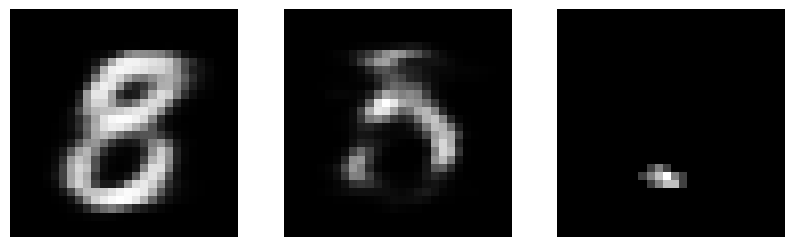

In [ ]:
text_query1 = '24+59'
generated_images21 = generate_images_from_text(text2image4_50, text_query1)

generated_images21 = generated_images21 * 255.0

plt.figure(figsize=(10, 5))
for i in range(generated_images21.shape[0]):
    plt.subplot(1, generated_images21.shape[0], i + 1)
    plt.imshow(generated_images21[i].astype(int), cmap='gray')
    plt.axis('off')
plt.show()

1/1 [==============================] - 0s 34ms/step


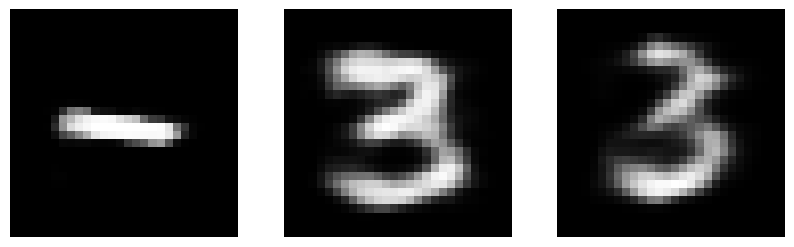

In [ ]:
text_query2 = '26-59'
generated_images22 = generate_images_from_text(text2image4_50, text_query2)

generated_images22 = generated_images22 * 255.0

plt.figure(figsize=(10, 5))
for i in range(generated_images22.shape[0]):
    plt.subplot(1, generated_images22.shape[0], i + 1)
    plt.imshow(generated_images22[i].astype(int), cmap='gray')
    plt.axis('off')
plt.show()

1/1 [==============================] - 0s 28ms/step


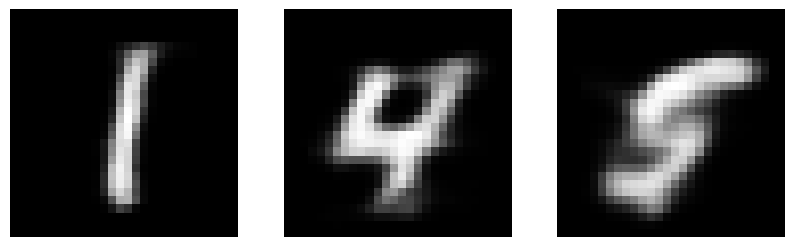

In [ ]:
text_query3 = '89+56'
generated_images23 = generate_images_from_text(text2image4_50, text_query3)

generated_images23 = generated_images23 * 255.0

plt.figure(figsize=(10, 5))
for i in range(generated_images23.shape[0]):
    plt.subplot(1, generated_images23.shape[0], i + 1)
    plt.imshow(generated_images23[i].astype(int), cmap='gray')
    plt.axis('off')
plt.show()


---
---
---

# Part 2: Multiplication
The cell below will create the multiplication dataset used in this part of the assignment.

11490434/11490434 [==============================] - 0s 0us/step
(10000,) (10000, 5, 28, 28) (10000,) (10000, 5, 28, 28)
Query #5834

X_text: "58*34" = y_text: "1972 "


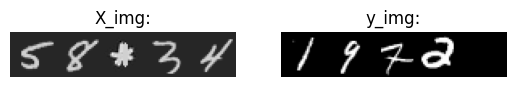

Query #3182

X_text: "31*82" = y_text: "2542 "


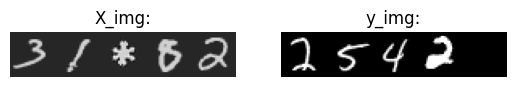

Query #6036

X_text: "60*36" = y_text: "2160 "


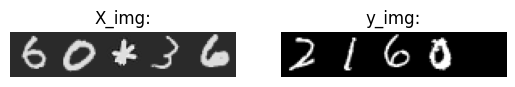

Query #511

X_text: "5*11 " = y_text: "55   "


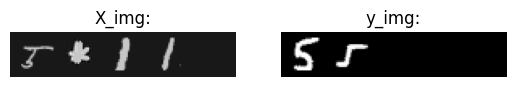

Query #8383

X_text: "83*83" = y_text: "6889 "


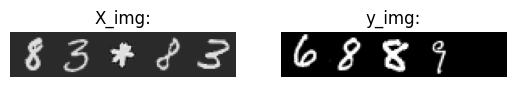

Query #2269

X_text: "22*69" = y_text: "1518 "


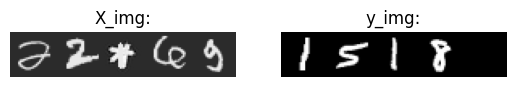

Query #9225

X_text: "92*25" = y_text: "2300 "


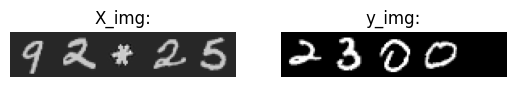

Query #2707

X_text: "27*7 " = y_text: "189  "


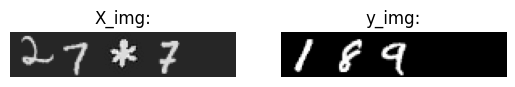

Query #4650

X_text: "46*50" = y_text: "2300 "


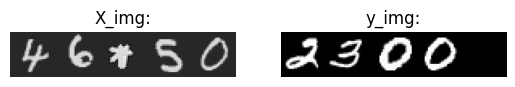

Query #5289

X_text: "52*89" = y_text: "4628 "


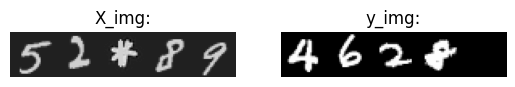

In [ ]:
# Illustrate the generated query/answer pairs

unique_characters = '0123456789* '       # All unique characters that are used in the queries (13 in total: digits 0-9, 2 operands [+, -], and a space character ' '.)
highest_integer = 99                      # Highest value of integers contained in the queries

max_int_length = len(str(highest_integer))# Maximum number of characters in an integer
max_query_length = max_int_length * 2 + 1 # Maximum length of the query string (consists of two integers and an operand [e.g. '22+10'])
max_answer_length = 5    # Maximum length of the answer string (the longest resulting query string is ' 99*(-99)'='-9801')

# Create the data (might take around a minute)
(MNIST_data, MNIST_labels), _ = tf.keras.datasets.mnist.load_data()
X_text, X_img, y_text, y_img = create_data(highest_integer, operands=['*'])
print(X_text.shape, X_img.shape, y_text.shape, y_img.shape)


## Display the samples that were created
def display_sample(n):
    labels = ['X_img:', 'y_img:']
    for i, data in enumerate([X_img, y_img]):
        plt.subplot(1,2,i+1)
        # plt.set_figheight(15)
        plt.axis('off')
        plt.title(labels[i])
        plt.imshow(np.hstack(data[n]), cmap='gray')
    print('='*50, f'\nQuery #{n}\n\nX_text: "{X_text[n]}" = y_text: "{y_text[n]}"')
    plt.show()

for _ in range(10):
    display_sample(np.random.randint(0, 10000, 1)[0])

Import libraries

In [ ]:
from tensorflow.keras.layers import Dense, RNN, LSTM, Flatten, TimeDistributed, LSTMCell, MaxPooling2D
from tensorflow.keras.layers import RepeatVector, Conv2D, SimpleRNN, GRU, Reshape, ConvLSTM2D, Conv2DTranspose, LayerNormalization
from keras.layers import Input, Conv2D, MaxPool2D, Dense,MaxPooling2D
from keras.layers import AveragePooling2D, Flatten, Activation, Bidirectional
from keras.layers import BatchNormalization, Dropout
from keras.layers import Concatenate, Add, Multiply, Lambda
from keras.layers import UpSampling2D, Reshape
from keras.layers import add,concatenate
from keras.layers import Reshape
from keras.models import Model
from keras.layers import LSTM,GRU
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from keras.preprocessing.sequence import pad_sequences
import pandas as pd

Helper functions

In [ ]:
def encode_labels(labels, max_len=3):
  n = len(labels)
  length = len(labels[0])
  char_map = dict(zip(unique_characters, range(len(unique_characters))))
  one_hot = np.zeros([n, length, len(unique_characters)])
  for i, label in enumerate(labels):
      m = np.zeros([length, len(unique_characters)])
      for j, char in enumerate(label):
          m[j, char_map[char]] = 1
      one_hot[i] = m

  return one_hot


def decode_labels(labels):
    pred = np.argmax(labels, axis=1)
    predicted = ''.join([unique_characters[i] for i in pred])

    return predicted

In [ ]:
X_text_onehot_m = encode_labels(X_text)
y_text_onehot_m = encode_labels(y_text)

print(X_text_onehot_m.shape, y_text_onehot_m.shape)

(10000, 5, 12) (10000, 5, 12)


Text-to-text RNN Model for multiplication

In [ ]:
def build_text2text_model_multiplication():

    # We start by initializing a sequential model
    text2text = tf.keras.Sequential()

    # "Encode" the input sequence using an RNN, producing an output of size 256.
    # In this case the size of our input vectors is [5, 13] as we have queries of length 5 and 13 unique characters. Each of these 5 elements in the query will be fed to the network one by one,
    # as shown in the image above (except with 5 elements).
    # Hint: In other applications, where your input sequences have a variable length (e.g. sentences), you would use input_shape=(None, unique_characters).
    text2text.add(LSTM(256, input_shape=(None, len(unique_characters))))

    # As the decoder RNN's input, repeatedly provide with the last output of RNN for each time step. Repeat 3 times as that's the maximum length of the output (e.g. '  1-99' = '-98')
    # when using 2-digit integers in queries. In other words, the RNN will always produce 3 characters as its output.
    text2text.add(RepeatVector(max_answer_length))

    # By setting return_sequences to True, return not only the last output but all the outputs so far in the form of (num_samples, timesteps, output_dim). This is necessary as TimeDistributed in the below expects
    # the first dimension to be the timesteps.
    text2text.add(LSTM(256, return_sequences=True))

    # Apply a dense layer to the every temporal slice of an input. For each of step of the output sequence, decide which character should be chosen.
    text2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    # Next we compile the model using categorical crossentropy as our loss function.
    text2text.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    text2text.summary()

    return text2text



#### Split 50% train 50% test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_text_onehot_m, y_text_onehot_m, test_size=0.5, random_state=0)
text2text_m = build_text2text_model_multiplication()
history_m=text2text_m.fit(X_train,y_train,epochs=20,batch_size=10,validation_split=0.1)
results_m = text2text_m.evaluate(X_test, y_test)
print("test loss, test acc:", results_m)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 256)               275456    
                                                                 
 repeat_vector_1 (RepeatVec  (None, 5, 256)            0         
 tor)                                                            
                                                                 
 lstm_4 (LSTM)               (None, 5, 256)            525312    
                                                                 
 time_distributed_1 (TimeDi  (None, 5, 12)             3084      
 stributed)                                                      
                                                                 
Total params: 803852 (3.07 MB)
Trainable params: 803852 (3.07 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/20
450/450

#### Split 75% trai 25% test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_text_onehot_m, y_text_onehot_m, test_size=0.1, random_state=0)
text2text_m1 = build_text2text_model_multiplication()
history_m1=text2text_m1.fit(X_train,y_train,epochs=20,batch_size=10,validation_split=0.1)
results_m1 = text2text_m1.evaluate(X_test, y_test)
print("test loss, test acc:", results_m1)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_5 (LSTM)               (None, 256)               275456    
                                                                 
 repeat_vector_2 (RepeatVec  (None, 5, 256)            0         
 tor)                                                            
                                                                 
 lstm_6 (LSTM)               (None, 5, 256)            525312    
                                                                 
 time_distributed_2 (TimeDi  (None, 5, 12)             3084      
 stributed)                                                      
                                                                 
Total params: 803852 (3.07 MB)
Trainable params: 803852 (3.07 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/20
810/810

#### Split 90% train 10% test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_text_onehot_m, y_text_onehot_m, test_size=0.1, random_state=0)
text2text_m2 = build_text2text_model_multiplication()
history_m2=text2text_m2.fit(X_train,y_train,epochs=20,batch_size=10,validation_split=0.1)
results_m2 = text2text_m2.evaluate(X_test, y_test)
print("test loss, test acc:", results_m2)

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_7 (LSTM)               (None, 256)               275456    
                                                                 
 repeat_vector_3 (RepeatVec  (None, 5, 256)            0         
 tor)                                                            
                                                                 
 lstm_8 (LSTM)               (None, 5, 256)            525312    
                                                                 
 time_distributed_3 (TimeDi  (None, 5, 12)             3084      
 stributed)                                                      
                                                                 
Total params: 803852 (3.07 MB)
Trainable params: 803852 (3.07 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/20
810/810

In [ ]:
predictions_m = text2text_m.predict(X_test)

decoded_predictions_m = [decode_labels(pred) for pred in predictions_m]
decoded_true_labels_m = [decode_labels(true) for true in y_test]

# count = 0
for i in range (20):
    num=random.randint(1, len(decoded_predictions_m))
    print(f'Query: {decode_labels(X_test[num])} \nPrediction: {decoded_predictions_m[num]} \nTrue answer: {decoded_true_labels_m[num]} \n')
    # if decoded_true_labels_m[i] != decoded_predictions_m[i]:
    #     count += 1



32/32 [==============================] - 1s 3ms/step
Query: 87*46 
Prediction: 4082  
True answer: 4002  

Query: 74*50 
Prediction: 3700  
True answer: 3700  

Query: 84*82 
Prediction: 6868  
True answer: 6888  

Query: 45*32 
Prediction: 1480  
True answer: 1440  

Query: 49*59 
Prediction: 2791  
True answer: 2891  

Query: 7*4   
Prediction: 28    
True answer: 28    

Query: 79*13 
Prediction: 108   
True answer: 1027  

Query: 68*25 
Prediction: 1710  
True answer: 1700  

Query: 28*21 
Prediction: 518   
True answer: 588   

Query: 1*67  
Prediction: 69    
True answer: 67    

Query: 43*87 
Prediction: 3841  
True answer: 3741  

Query: 88*94 
Prediction: 8262  
True answer: 8272  

Query: 6*60  
Prediction: 380   
True answer: 360   

Query: 48*57 
Prediction: 2726  
True answer: 2736  

Query: 62*68 
Prediction: 4936  
True answer: 4216  

Query: 14*67 
Prediction: 802   
True answer: 938   

Query: 24*70 
Prediction: 1640  
True answer: 1680  

Query: 75*27 
Prediction: 192

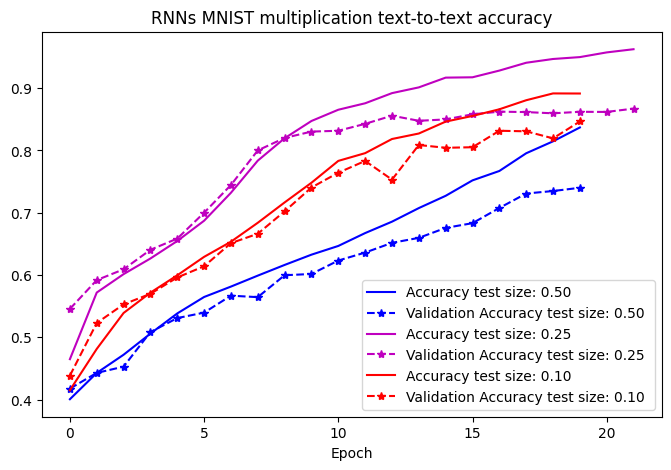

In [ ]:
# Create DataFrames from the training history for both models
df_history_im = pd.DataFrame(history_m.history)  # Fix: Correct variable name
df_history_im1 = pd.DataFrame(history_m1.history)
df_history_im2 = pd.DataFrame(history_m2.history)

# Define custom labels for the legend
legend_labels = ["Accuracy test size: 0.50 ", "Validation Accuracy test size: 0.50 ",
                 "Accuracy test size: 0.25", "Validation Accuracy test size: 0.25",
                 "Accuracy test size: 0.10", "Validation Accuracy test size: 0.10"]

# Plot only accuracy and validation accuracy for both models with custom labels
ax = df_history_im.plot(figsize=(8, 5), grid=True, xlabel="Epoch",
                         y=["accuracy", "val_accuracy"],
                         style={"accuracy": "b-", "val_accuracy": "b--*"},
                         title='RNNs MNIST multiplication text-to-text accuracy')

df_history_im1.plot(ax=ax, y=["accuracy", "val_accuracy"],
                    style={"accuracy": "m-", "val_accuracy": "m--*"})
df_history_im2.plot(ax=ax, y=["accuracy", "val_accuracy"],
                    style={"accuracy": "r-", "val_accuracy": "r--*"})

# Show the legend with the custom labels
ax.legend(legend_labels)

# Show the plot
plt.show()


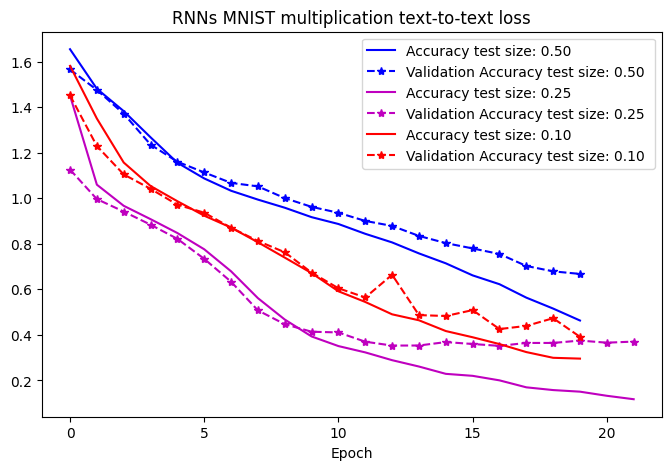

In [ ]:

ax = df_history_im.plot(figsize=(8, 5), grid=True, xlabel="Epoch",
                         y=["loss", "val_loss"],
                         style={"loss": "b-", "val_loss": "b--*"},
                         title='RNNs MNIST multiplication text-to-text loss')

df_history_im1.plot(ax=ax, y=["loss", "val_loss"],
                    style={"loss": "m-", "val_loss": "m--*"})
df_history_im2.plot(ax=ax, y=["loss", "val_loss"],
                    style={"loss": "r-", "val_loss": "r--*"})

# Show the legend with the custom labels
ax.legend(legend_labels)

# Show the plot
plt.show()

#### Add layers text to text

In [ ]:

def build_text2text_model_multiplication_layers():
    drop_out_rate = 0.2

    text2text = tf.keras.Sequential()
    text2text.add(LSTM(512, input_shape=(None, len(unique_characters)), return_sequences=True))

    text2text.add(LayerNormalization())
    text2text.add(LSTM(512,))
    text2text.add(LayerNormalization())
    text2text.add(Dropout(drop_out_rate))

    text2text.add(RepeatVector(max_answer_length))

    text2text.add(LSTM(512, return_sequences=True))

    text2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    #optimizer = Adam(learning_rate=0.001, clipnorm=1.0)
    text2text.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    text2text.summary()

    return text2text




In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

X_train, X_test, y_train, y_test = train_test_split(X_text_onehot_m, y_text_onehot_m, test_size=0.1, random_state=0)
text2text_m1 = build_text2text_model_multiplication_layers()

history_m1=text2text_m1.fit(X_train,y_train,epochs=10,batch_size=10,validation_split=0.1,callbacks=[early_stopping]) #batch size 32
results_m1 = text2text_m1.evaluate(X_test, y_test)
print("test loss, test acc:", results_m1)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, None, 512)         1075200   
                                                                 
 layer_normalization (Layer  (None, None, 512)         1024      
 Normalization)                                                  
                                                                 
 lstm_1 (LSTM)               (None, 512)               2099200   
                                                                 
 layer_normalization_1 (Lay  (None, 512)               1024      
 erNormalization)                                                
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 repeat_vector (RepeatVecto  (None, 5, 512)            0

In [ ]:

def build_text2text_model_multiplication_layers2():
    drop_out_rate = 0.2

    text2text = tf.keras.Sequential()
    text2text.add(LSTM(512, input_shape=(None, len(unique_characters)), return_sequences=True))


    text2text.add(LSTM(512,return_sequences=True))
    text2text.add(LayerNormalization())
    text2text.add(Dropout(drop_out_rate))
    text2text.add(LSTM(512,))


    text2text.add(RepeatVector(max_answer_length))

    text2text.add(LSTM(512, return_sequences=True))

    text2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    #optimizer = Adam(learning_rate=0.001, clipnorm=1.0)
    text2text.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    text2text.summary()

    return text2text





In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

X_train, X_test, y_train, y_test = train_test_split(X_text_onehot_m, y_text_onehot_m, test_size=0.1, random_state=0)
text2text_l2 = build_text2text_model_multiplication_layers2()

history_l2=text2text_l2.fit(X_train,y_train,epochs=10,batch_size=10,validation_split=0.1,callbacks=[early_stopping]) #batch size 32
results_l2 = text2text_l2.evaluate(X_test, y_test)
print("test loss, test acc:", results_l2)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, None, 512)         1075200   
                                                                 
 lstm_4 (LSTM)               (None, None, 512)         2099200   
                                                                 
 layer_normalization_2 (Lay  (None, None, 512)         1024      
 erNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, None, 512)         0         
                                                                 
 lstm_5 (LSTM)               (None, 512)               2099200   
                                                                 
 repeat_vector_1 (RepeatVec  (None, 5, 512)            0         
 tor)                                                 

In [ ]:

def build_text2text_model_multiplication_layers_():
    drop_out_rate = 0.25

    text2text = tf.keras.Sequential()
    text2text.add(LSTM(512, input_shape=(None, len(unique_characters)), return_sequences=True))

    text2text.add(LayerNormalization())
    text2text.add(LSTM(512,))
    text2text.add(LayerNormalization())
    text2text.add(Dropout(drop_out_rate))

    text2text.add(RepeatVector(max_answer_length))

    text2text.add(LSTM(256, return_sequences=True))

    text2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    optimizer = Adam(learning_rate=0.001, clipnorm=1.0)
    text2text.compile(loss='categorical_crossentropy', optimizer= optimizer, metrics=['accuracy'])
    text2text.summary()

    return text2text





In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

X_train, X_test, y_train, y_test = train_test_split(X_text_onehot_m, y_text_onehot_m, test_size=0.1, random_state=0)
text2text_l3 = build_text2text_model_multiplication_layers_()

history_l3=text2text_l3.fit(X_train,y_train,epochs=10,batch_size=10,validation_split=0.1,callbacks=[early_stopping])
results_l3 = text2text_l3.evaluate(X_test, y_test)
print("test loss, test acc:", results_l3)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_7 (LSTM)               (None, None, 512)         1075200   
                                                                 
 layer_normalization_3 (Lay  (None, None, 512)         1024      
 erNormalization)                                                
                                                                 
 lstm_8 (LSTM)               (None, 512)               2099200   
                                                                 
 layer_normalization_4 (Lay  (None, 512)               1024      
 erNormalization)                                                
                                                                 
 dropout_2 (Dropout)         (None, 512)               0         
                                                                 
 repeat_vector_2 (RepeatVec  (None, 5, 512)           

In [ ]:

def build_text2text_model_multiplication_layers_best():
    drop_out_rate = 0.25

    text2text = tf.keras.Sequential()
    text2text.add(LSTM(256, input_shape=(None, len(unique_characters)), return_sequences=True))

    text2text.add(LayerNormalization())
    text2text.add(LSTM(256,))
    text2text.add(LayerNormalization())
    text2text.add(Dropout(drop_out_rate))

    text2text.add(RepeatVector(max_answer_length))

    text2text.add(LSTM(512, return_sequences=True))

    text2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))


    text2text.compile(loss='categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])
    text2text.summary()

    return text2text





In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

X_train, X_test, y_train, y_test = train_test_split(X_text_onehot_m, y_text_onehot_m, test_size=0.1, random_state=0)
text2text_l4 = build_text2text_model_multiplication_layers_best()

history_l4=text2text_l4.fit(X_train,y_train,epochs=30,batch_size=10,validation_split=0.1,callbacks=[early_stopping])
results_l4 = text2text_l4.evaluate(X_test, y_test)
print("test loss, test acc:", results_l4)

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_19 (LSTM)              (None, None, 256)         275456    
                                                                 
 layer_normalization_5 (Lay  (None, None, 256)         512       
 erNormalization)                                                
                                                                 
 lstm_20 (LSTM)              (None, 256)               525312    
                                                                 
 layer_normalization_6 (Lay  (None, 256)               512       
 erNormalization)                                                
                                                                 
 dropout_3 (Dropout)         (None, 256)               0         
                                                                 
 repeat_vector_7 (RepeatVec  (None, 5, 256)           

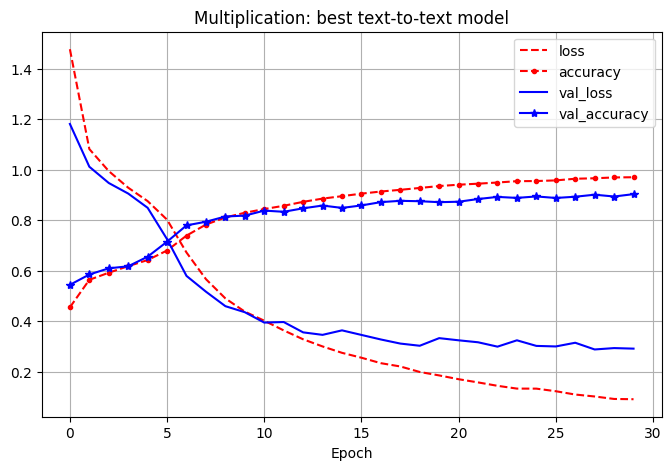

In [ ]:
pd.DataFrame(history_l4.history).plot(
figsize=(8, 5), grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"],title='Multiplication: best text-to-text model')
plt.show()

#### Image-to-text RNN Model for multiplication

In [ ]:
#simple one
def build_img2text_model_multiplication():

    img2text = tf.keras.Sequential()

    img2text.add(LSTM(256, input_shape=(max_query_length, 784)))

    img2text.add(RepeatVector(max_answer_length))

    img2text.add(LSTM(256, return_sequences=True))

    img2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    img2text.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    img2text.summary()

    return img2text



#### 75% train 25% test

In [ ]:
(X_train, X_test, X_train_text, X_test_text, y_train, y_test) = train_test_split(
     X_img, X_text_onehot_m, y_text_onehot_m,
     test_size=0.25, random_state=0
)

X_train_flatten = X_train.reshape(X_train.shape[0], X_train.shape[1],-1)
print(X_train_flatten.shape)
X_test_flatten = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)
print(X_test_flatten.shape)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

img2text_1 = build_img2text_model_multiplication()
history_1=img2text_1.fit(X_train_flatten, y_train, epochs=20, batch_size=10, validation_split=0.1, callbacks=[early_stopping])
results_1 = img2text_1.evaluate(X_test_flatten, y_test)
print("test loss, test acc:", results_1)

(7500, 5, 784)
(2500, 5, 784)
Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_22 (LSTM)              (None, 256)               1065984   
                                                                 
 repeat_vector_8 (RepeatVec  (None, 5, 256)            0         
 tor)                                                            
                                                                 
 lstm_23 (LSTM)              (None, 5, 256)            525312    
                                                                 
 time_distributed_8 (TimeDi  (None, 5, 12)             3084      
 stributed)                                                      
                                                                 
Total params: 1594380 (6.08 MB)
Trainable params: 1594380 (6.08 MB)
Non-trainable params: 0 (0.00 Byte)
____________________________________________________

#### 90% train 10% test

In [ ]:
(X_train, X_test, X_train_text, X_test_text, y_train, y_test) = train_test_split(
     X_img, X_text_onehot_m, y_text_onehot_m,
     test_size=0.1, random_state=0
)

X_train_flatten = X_train.reshape(X_train.shape[0], X_train.shape[1],-1)
print(X_train_flatten.shape)
X_test_flatten = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)
print(X_test_flatten.shape)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

img2text_2 = build_img2text_model_multiplication()
history_2=img2text_2.fit(X_train_flatten, y_train, epochs=20, batch_size=10, validation_split=0.1, callbacks=[early_stopping])
results_2 = img2text_2.evaluate(X_test_flatten, y_test)
print("test loss, test acc:", results_2)

(9000, 5, 784)
(1000, 5, 784)
Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_24 (LSTM)              (None, 256)               1065984   
                                                                 
 repeat_vector_9 (RepeatVec  (None, 5, 256)            0         
 tor)                                                            
                                                                 
 lstm_25 (LSTM)              (None, 5, 256)            525312    
                                                                 
 time_distributed_9 (TimeDi  (None, 5, 12)             3084      
 stributed)                                                      
                                                                 
Total params: 1594380 (6.08 MB)
Trainable params: 1594380 (6.08 MB)
Non-trainable params: 0 (0.00 Byte)
____________________________________________________

#### Add additional layers image to text

In [ ]:
#one extra layer
def build_img2text_model_multiplication_layers():
    drop_out_rate = 0.25

    img2text = tf.keras.Sequential()
    img2text.add(LSTM(256, input_shape=(max_query_length, 784), return_sequences=True))

    img2text.add(LayerNormalization())
    img2text.add(LSTM(256,))
    img2text.add(LayerNormalization())
    img2text.add(Dropout(drop_out_rate))

    img2text.add(RepeatVector(max_answer_length))

    img2text.add(LSTM(512, return_sequences=True))

    img2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))


    img2text.compile(loss='categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])
    img2text.summary()

    return img2text





In [ ]:
(X_train, X_test, X_train_text, X_test_text, y_train, y_test) = train_test_split(
     X_img, X_text_onehot_m, y_text_onehot_m,
     test_size=0.25, random_state=0
)

X_train_flatten = X_train.reshape(X_train.shape[0], X_train.shape[1],-1)
print(X_train_flatten.shape)
X_test_flatten = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)
print(X_test_flatten.shape)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

img2text_il1 = build_img2text_model_multiplication_layers()
history_il1=img2text_il1.fit(X_train_flatten, y_train, epochs=20, batch_size=10, validation_split=0.1, callbacks=[early_stopping])
results_il1 = img2text_il1.evaluate(X_test_flatten, y_test)
print("test loss, test acc:", results_il1)

(7500, 5, 784)
(2500, 5, 784)
Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_26 (LSTM)              (None, 5, 256)            1065984   
                                                                 
 layer_normalization_7 (Lay  (None, 5, 256)            512       
 erNormalization)                                                
                                                                 
 lstm_27 (LSTM)              (None, 256)               525312    
                                                                 
 layer_normalization_8 (Lay  (None, 256)               512       
 erNormalization)                                                
                                                                 
 dropout_4 (Dropout)         (None, 256)               0         
                                                                 
 repeat_vector_10 (Repe

In [ ]:
#one extra layer with 512 units per layer
def build_img2text_model_multiplication_layers2():
    drop_out_rate = 0.25

    img2text = tf.keras.Sequential()
    img2text.add(LSTM(512, input_shape=(max_query_length, 784), return_sequences=True))

    img2text.add(LayerNormalization())
    img2text.add(LSTM(512,))
    img2text.add(LayerNormalization())
    img2text.add(Dropout(drop_out_rate))

    img2text.add(RepeatVector(max_answer_length))

    img2text.add(LSTM(512, return_sequences=True))

    img2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))


    img2text.compile(loss='categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])
    img2text.summary()

    return img2text





In [ ]:
(X_train, X_test, X_train_text, X_test_text, y_train, y_test) = train_test_split(
     X_img, X_text_onehot_m, y_text_onehot_m,
     test_size=0.25, random_state=0
)

X_train_flatten = X_train.reshape(X_train.shape[0], X_train.shape[1],-1)
print(X_train_flatten.shape)
X_test_flatten = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)
print(X_test_flatten.shape)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

img2text_il2 = build_img2text_model_multiplication_layers2()
history_il2=img2text_il2.fit(X_train_flatten, y_train, epochs=20, batch_size=10, validation_split=0.1, callbacks=[early_stopping])
results_il2 = img2text_il2.evaluate(X_test_flatten, y_test)
print("test loss, test acc:", results_il2)

(7500, 5, 784)
(2500, 5, 784)
Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_29 (LSTM)              (None, 5, 512)            2656256   
                                                                 
 layer_normalization_9 (Lay  (None, 5, 512)            1024      
 erNormalization)                                                
                                                                 
 lstm_30 (LSTM)              (None, 512)               2099200   
                                                                 
 layer_normalization_10 (La  (None, 512)               1024      
 yerNormalization)                                               
                                                                 
 dropout_5 (Dropout)         (None, 512)               0         
                                                                 
 repeat_vector_11 (Repe

In [ ]:
#two extra layers
def build_img2text_model_multiplication_layers3():
    drop_out_rate = 0.25

    img2text = tf.keras.Sequential()
    img2text.add(LSTM(256, input_shape=(max_query_length, 784), return_sequences=True))

    img2text.add(LayerNormalization())
    img2text.add(LSTM(256,return_sequences=True))
    img2text.add(LayerNormalization())
    img2text.add(Dropout(drop_out_rate))
    img2text.add(LSTM(256,))
    img2text.add(LayerNormalization())
    img2text.add(Dropout(drop_out_rate))

    img2text.add(RepeatVector(max_answer_length))

    img2text.add(LSTM(256, return_sequences=True))

    img2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))


    img2text.compile(loss='categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])
    img2text.summary()

    return img2text





In [ ]:
(X_train, X_test, X_train_text, X_test_text, y_train, y_test) = train_test_split(
     X_img, X_text_onehot_m, y_text_onehot_m,
     test_size=0.25, random_state=0
)

X_train_flatten = X_train.reshape(X_train.shape[0], X_train.shape[1],-1)
print(X_train_flatten.shape)
X_test_flatten = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)
print(X_test_flatten.shape)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

img2text_il3 = build_img2text_model_multiplication_layers3()
history_il3=img2text_il3.fit(X_train_flatten, y_train, epochs=20, batch_size=10, validation_split=0.1, callbacks=[early_stopping])
results_il3 = img2text_il3.evaluate(X_test_flatten, y_test)
print("test loss, test acc:", results_il3)

(7500, 5, 784)
(2500, 5, 784)
Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_32 (LSTM)              (None, 5, 256)            1065984   
                                                                 
 layer_normalization_11 (La  (None, 5, 256)            512       
 yerNormalization)                                               
                                                                 
 lstm_33 (LSTM)              (None, 5, 256)            525312    
                                                                 
 layer_normalization_12 (La  (None, 5, 256)            512       
 yerNormalization)                                               
                                                                 
 dropout_6 (Dropout)         (None, 5, 256)            0         
                                                                 
 lstm_34 (LSTM)        

In [ ]:
#two extra layers
def build_img2text_model_multiplication_layers_4():
    drop_out_rate = 0.25

    img2text = tf.keras.Sequential()
    img2text.add(LSTM(256, input_shape=(max_query_length, 784), return_sequences=True))

    img2text.add(LayerNormalization())
    img2text.add(LSTM(256,return_sequences=True))
    img2text.add(LayerNormalization())
    img2text.add(Dropout(drop_out_rate))
    img2text.add(LSTM(256,return_sequences=True))
    img2text.add(LayerNormalization())
    img2text.add(Dropout(drop_out_rate))
    img2text.add(LSTM(256,))
    img2text.add(LayerNormalization())
    img2text.add(Dropout(drop_out_rate))

    img2text.add(RepeatVector(max_answer_length))

    img2text.add(LSTM(256, return_sequences=True))

    img2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))


    img2text.compile(loss='categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])
    img2text.summary()

    return img2text





In [ ]:
(X_train, X_test, X_train_text, X_test_text, y_train, y_test) = train_test_split(
     X_img, X_text_onehot_m, y_text_onehot_m,
     test_size=0.25, random_state=0
)

X_train_flatten = X_train.reshape(X_train.shape[0], X_train.shape[1],-1)
print(X_train_flatten.shape)
X_test_flatten = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)
print(X_test_flatten.shape)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

img2text_il4 = build_img2text_model_multiplication_layers_4()
history_il4=img2text_il4.fit(X_train_flatten, y_train, epochs=10, batch_size=10, validation_split=0.1, callbacks=[early_stopping])
results_il4 = img2text_il4.evaluate(X_test_flatten, y_test)
print("test loss, test acc:", results_il4)

(7500, 5, 784)
(2500, 5, 784)
Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_36 (LSTM)              (None, 5, 256)            1065984   
                                                                 
 layer_normalization_14 (La  (None, 5, 256)            512       
 yerNormalization)                                               
                                                                 
 lstm_37 (LSTM)              (None, 5, 256)            525312    
                                                                 
 layer_normalization_15 (La  (None, 5, 256)            512       
 yerNormalization)                                               
                                                                 
 dropout_8 (Dropout)         (None, 5, 256)            0         
                                                                 
 lstm_38 (LSTM)        

In [ ]:
#two extra layers
def build_img2text_model_multiplication_layers_5():
    drop_out_rate = 0.25

    img2text = tf.keras.Sequential()
    img2text.add(LSTM(256, input_shape=(max_query_length, 784), return_sequences=True))

    img2text.add(LayerNormalization())
    img2text.add(LSTM(256,return_sequences=True))
    img2text.add(LayerNormalization())
    img2text.add(Dropout(drop_out_rate))
    img2text.add(LSTM(256,))
    img2text.add(LayerNormalization())
    img2text.add(Dropout(drop_out_rate))

    img2text.add(RepeatVector(max_answer_length))

    img2text.add(LSTM(512, return_sequences=True))

    img2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))


    img2text.compile(loss='categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])
    img2text.summary()

    return img2text





In [ ]:
(X_train, X_test, X_train_text, X_test_text, y_train, y_test) = train_test_split(
     X_img, X_text_onehot_m, y_text_onehot_m,
     test_size=0.25, random_state=0
)

X_train_flatten = X_train.reshape(X_train.shape[0], X_train.shape[1],-1)
print(X_train_flatten.shape)
X_test_flatten = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)
print(X_test_flatten.shape)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

img2text_il5 = build_img2text_model_multiplication_layers_5()
history_il5=img2text_il5.fit(X_train_flatten, y_train, epochs=50, batch_size=10, validation_split=0.1, callbacks=[early_stopping])
results_il5 = img2text_il5.evaluate(X_test_flatten, y_test)
print("test loss, test acc:", results_il5)

(7500, 5, 784)
(2500, 5, 784)
Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_41 (LSTM)              (None, 5, 256)            1065984   
                                                                 
 layer_normalization_18 (La  (None, 5, 256)            512       
 yerNormalization)                                               
                                                                 
 lstm_42 (LSTM)              (None, 5, 256)            525312    
                                                                 
 layer_normalization_19 (La  (None, 5, 256)            512       
 yerNormalization)                                               
                                                                 
 dropout_11 (Dropout)        (None, 5, 256)            0         
                                                                 
 lstm_43 (LSTM)        

In [ ]:
#two extra layers
def build_img2text_model_multiplication_layers_best():
    drop_out_rate = 0.25

    img2text = tf.keras.Sequential()
    img2text.add(LSTM(128, input_shape=(max_query_length, 784), return_sequences=True))

    img2text.add(LayerNormalization())
    img2text.add(LSTM(128,return_sequences=True))
    img2text.add(LayerNormalization())
    img2text.add(Dropout(drop_out_rate))
    img2text.add(LSTM(256))
    img2text.add(LayerNormalization())
    img2text.add(Dropout(drop_out_rate))

    img2text.add(RepeatVector(max_answer_length))

    img2text.add(LSTM(256, return_sequences=True))

    img2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))


    img2text.compile(loss='categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])
    img2text.summary()

    return img2text

# img2text_m = tf.keras.Sequential()
# img2text_m.add(LSTM(512, input_shape=(max_query_length, 784), return_sequences=True))
# img2text_m.add(Dropout(drop_out_rate))
# img2text_m.add(Bidirectional(LSTM(256,)))  # Bidirectional LSTM
# img2text_m.add(RepeatVector(max_answer_length))
# img2text_m.add(LSTM(256, return_sequences=True))
# img2text_m.add(Dropout(drop_out_rate))
# img2text_m.add(BatchNormalization())
# img2text_m.add(TimeDistributed(tf.keras.layers.Dense(256, activation='relu')))
# img2text_m.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))





In [ ]:
(X_train, X_test, X_train_text, X_test_text, y_train, y_test) = train_test_split(
     X_img, X_text_onehot_m, y_text_onehot_m,
     test_size=0.25, random_state=0
)

X_train_flatten = X_train.reshape(X_train.shape[0], X_train.shape[1],-1)
print(X_train_flatten.shape)
X_test_flatten = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)
print(X_test_flatten.shape)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

img2text_il6 = build_img2text_model_multiplication_layers_best()
history_il6=img2text_il6.fit(X_train_flatten, y_train, epochs=50, batch_size=10, validation_split=0.1, callbacks=[early_stopping])
results_il6 = img2text_il6.evaluate(X_test_flatten, y_test)
print("test loss, test acc:", results_il6)

(7500, 5, 784)
(2500, 5, 784)
Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_45 (LSTM)              (None, 5, 128)            467456    
                                                                 
 layer_normalization_21 (La  (None, 5, 128)            256       
 yerNormalization)                                               
                                                                 
 lstm_46 (LSTM)              (None, 5, 128)            131584    
                                                                 
 layer_normalization_22 (La  (None, 5, 128)            256       
 yerNormalization)                                               
                                                                 
 dropout_13 (Dropout)        (None, 5, 128)            0         
                                                                 
 lstm_47 (LSTM)        

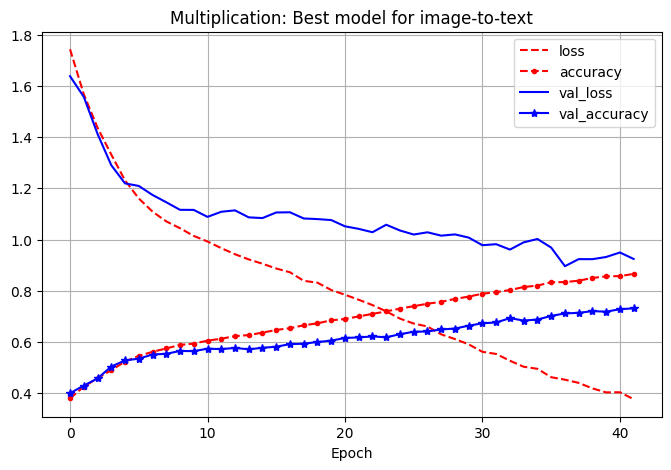

In [ ]:
pd.DataFrame(history_il6.history).plot(
figsize=(8, 5),  grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"],title='Multiplication: Best model for image-to-text')
plt.show()

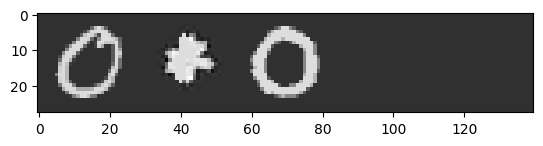

In [ ]:
#stack the five images to create input images
stacked_image=[]
for i in range(X_img.shape[0]):
    stacked_image.append(np.concatenate([X_img[i][0], X_img[i][1], X_img[i][2], X_img[i][3], X_img[i][4]], axis=1))
s_image=np.array(stacked_image)

plt.imshow(s_image[0], cmap='gray')
plt.show()


In [ ]:
#with cnn
import tensorflow as tf
from tensorflow.keras.layers import (
    Conv2D, BatchNormalization, MaxPooling2D, Dropout, Reshape, LSTM, Bidirectional, Flatten, RepeatVector, TimeDistributed, Dense
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping
from sklearn.model_selection import train_test_split

drop_out_rate=0.25


# Normalize pixel values to [0, 1]
X_images = s_image / 255.0

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_images, y_text_onehot_m, test_size=0.2, random_state=42)

# Learning rate scheduler
def lr_schedule(epoch):
    lr = 1e-3
    if epoch > 5:
        lr *= 1e-1
    elif epoch > 10:
        lr *= 1e-2
    return lr

optimizer = Adam(learning_rate=lr_schedule(0))

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_mu1 = tf.keras.models.Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(28, 140, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    Dropout(drop_out_rate),
    BatchNormalization(momentum=0.9),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu'),
    Dropout(drop_out_rate),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Reshape((5, -1)),
    LSTM(128, return_sequences=True),
    LSTM(128, return_sequences=True),
    # Bidirectional(LSTM(256, return_sequences=True)),
    Dropout(drop_out_rate),
    LayerNormalization(),
    Flatten(),
    RepeatVector(max_answer_length),
    LSTM(256, return_sequences=True),
    Dropout(drop_out_rate),
    # TimeDistributed(Dense(64, activation='relu')),
    TimeDistributed(Dense(len(unique_characters), activation='softmax'))
])

# Compile the model
model_mu1.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Reshape the data to include the channel dimension
X_train_reshaped = X_train.reshape((X_train.shape[0], 28, 140, 1))
X_test_reshaped = X_test.reshape((X_test.shape[0], 28, 140, 1))

# Train the model
history_mu1 = model_mu1.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_data=(X_test_reshaped, y_test), callbacks=[early_stopping, LearningRateScheduler(lr_schedule)])

# Evaluate the model
loss, accuracy = model_mu1.evaluate(X_test_reshaped, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')


Epoch 1/50
250/250 [==============================] - 12s 27ms/step - loss: 1.7621 - accuracy: 0.3740 - val_loss: 2.5155 - val_accuracy: 0.1937 - lr: 0.0010
Epoch 2/50
250/250 [==============================] - 5s 19ms/step - loss: 1.5921 - accuracy: 0.4188 - val_loss: 4.6327 - val_accuracy: 0.2947 - lr: 0.0010
Epoch 3/50
250/250 [==============================] - 5s 19ms/step - loss: 1.4860 - accuracy: 0.4530 - val_loss: 1.5030 - val_accuracy: 0.4520 - lr: 0.0010
Epoch 4/50
250/250 [==============================] - 5s 20ms/step - loss: 1.3751 - accuracy: 0.4818 - val_loss: 1.3911 - val_accuracy: 0.4771 - lr: 0.0010
Epoch 5/50
250/250 [==============================] - 5s 19ms/step - loss: 1.2907 - accuracy: 0.5042 - val_loss: 1.2839 - val_accuracy: 0.5037 - lr: 0.0010
Epoch 6/50
250/250 [==============================] - 5s 20ms/step - loss: 1.2206 - accuracy: 0.5245 - val_loss: 1.2486 - val_accuracy: 0.5152 - lr: 0.0010
Epoch 7/50
250/250 [==============================] - 5s 20ms/s

##### A different approach: Predict text on image and then calculate the arithmetic operation using cnns and rnns together

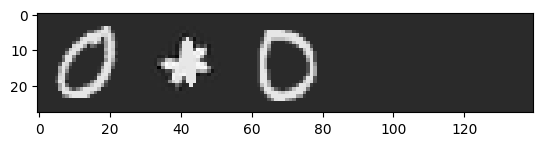

In [ ]:
#stack the five images to create input images
stacked_image=[]
for i in range(X_img.shape[0]):
    stacked_image.append(np.concatenate([X_img[i][0], X_img[i][1], X_img[i][2], X_img[i][3], X_img[i][4]], axis=1))
s_image=np.array(stacked_image)

plt.imshow(s_image[0], cmap='gray')
plt.show()


In [ ]:
#first attempt
X_text_labels_encoded = encode_labels(X_text)

# Preprocess the images
X_images = s_image / 255.0  # Normalize pixel values to [0, 1]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_images, X_text_labels_encoded, test_size=0.2, random_state=42)

model_im = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 140, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Reshape((5, -1)),  # Flatten before LSTM, assuming 5 time steps
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(64, activation='relu')),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(len(unique_characters), activation='softmax'))
])


# Compile the model
model_im.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Reshape the data to include the channel dimension
X_train_reshaped = X_train.reshape((X_train.shape[0], 28, 140, 1))
X_test_reshaped = X_test.reshape((X_test.shape[0], 28, 140, 1))

# Train the model_im
history_im=model_im.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model
loss, accuracy = model_im.evaluate(X_test_reshaped, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')

Epoch 1/10
225/225 [==============================] - 6s 10ms/step - loss: 2.0910 - accuracy: 0.2584 - val_loss: 1.9583 - val_accuracy: 0.2865
Epoch 2/10
225/225 [==============================] - 1s 6ms/step - loss: 1.8087 - accuracy: 0.3232 - val_loss: 1.6530 - val_accuracy: 0.3835
Epoch 3/10
225/225 [==============================] - 1s 6ms/step - loss: 1.4901 - accuracy: 0.4569 - val_loss: 1.3161 - val_accuracy: 0.5192
Epoch 4/10
225/225 [==============================] - 1s 6ms/step - loss: 1.1616 - accuracy: 0.5899 - val_loss: 1.0376 - val_accuracy: 0.6308
Epoch 5/10
225/225 [==============================] - 1s 6ms/step - loss: 0.9379 - accuracy: 0.6726 - val_loss: 0.9144 - val_accuracy: 0.6810
Epoch 6/10
225/225 [==============================] - 1s 7ms/step - loss: 0.8010 - accuracy: 0.7211 - val_loss: 0.7965 - val_accuracy: 0.7130
Epoch 7/10
225/225 [==============================] - 1s 6ms/step - loss: 0.7122 - accuracy: 0.7529 - val_loss: 0.7123 - val_accuracy: 0.7533
Epoch

In [ ]:
def calculate_results(expressions):
    results = []
    for expression in expressions:
        try:
            result = eval(expression)
            results.append(result)
        except Exception as e:
            results.append(f"Error: {str(e)}")
    return results


predictions = model_im.predict(X_test_reshaped)
# Decode the one-hot encoded predictions and real labels
decoded_predictions = [decode_labels(pred) for pred in predictions]
decoded_real_labels = [decode_labels(ys) for ys in y_test]


results_pred = calculate_results(decoded_predictions)
results_real = calculate_results(decoded_real_labels)

count=0
for expression_pred,expression_real, result_pred,result_real in zip(decoded_predictions,decoded_real_labels, results_pred,results_real):
    if result_pred==result_real:
      count=count+1
print(f'correct multiplication result: {count/len(results_real) * 100:.2f}%')

total_chars = 0
correct_chars = 0

# Calculate character-level accuracy
for true_chars, pred_chars in zip(decoded_real_labels, decoded_predictions):
    total_chars += max(len(true_chars), len(pred_chars))
    correct_chars += sum(t == p for t, p in zip(true_chars, pred_chars))

char_accuracy = correct_chars / total_chars

print(f'Character-level Accuracy: {char_accuracy * 100:.2f}%') #same as model accuracy


# Convert sequences of characters back to strings
y_pred_seqs = [''.join(seq) for seq in decoded_predictions]
y_test_seqs = [''.join(seq) for seq in decoded_real_labels]

# Calculate sequence-level accuracy
correct_seqs = sum(true_seq == pred_seq for true_seq, pred_seq in zip(y_test_seqs, y_pred_seqs))
sequence_accuracy = correct_seqs / len(y_test_seqs)

print(f'Sequence-level Accuracy: {sequence_accuracy * 100:.2f}%') #all the expression orrect->correct result of multiplication





63/63 [==============================] - 1s 3ms/step
correct multiplication result: 32.60%
Character-level Accuracy: 80.44%
Sequence-level Accuracy: 31.55%


In [ ]:
#best model

drop_out_rate=0.25

X_text_labels_encoded = encode_labels(X_text)

# Preprocess the images
X_images = s_image / 255.0  # Normalize pixel values to [0, 1]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_images, X_text_labels_encoded, test_size=0.2, random_state=42)

model_im2 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 140, 1)),
    BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    Dropout(drop_out_rate),
    BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu'),
    Dropout(drop_out_rate),
    BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Reshape((5, -1)),  # Flatten before LSTM, assuming 5 time steps
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(64, activation='relu')),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(len(unique_characters), activation='softmax'))
])


# Compile the model
model_im2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Reshape the data to include the channel dimension
X_train_reshaped = X_train.reshape((X_train.shape[0], 28, 140, 1))
X_test_reshaped = X_test.reshape((X_test.shape[0], 28, 140, 1))

# Train the model
history_im2=model_im2.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model
loss, accuracy = model_im2.evaluate(X_test_reshaped, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')

Epoch 1/10
225/225 [==============================] - 8s 21ms/step - loss: 0.3473 - accuracy: 0.9016 - val_loss: 2.4817 - val_accuracy: 0.0777
Epoch 2/10
225/225 [==============================] - 4s 18ms/step - loss: 0.0791 - accuracy: 0.9764 - val_loss: 2.4888 - val_accuracy: 0.0820
Epoch 3/10
225/225 [==============================] - 4s 18ms/step - loss: 0.0522 - accuracy: 0.9842 - val_loss: 0.3949 - val_accuracy: 0.8852
Epoch 4/10
225/225 [==============================] - 4s 19ms/step - loss: 0.0399 - accuracy: 0.9865 - val_loss: 0.3320 - val_accuracy: 0.9043
Epoch 5/10
225/225 [==============================] - 4s 18ms/step - loss: 0.0371 - accuracy: 0.9881 - val_loss: 0.1512 - val_accuracy: 0.9513
Epoch 6/10
225/225 [==============================] - 4s 18ms/step - loss: 0.0277 - accuracy: 0.9908 - val_loss: 0.1403 - val_accuracy: 0.9567
Epoch 7/10
225/225 [==============================] - 4s 19ms/step - loss: 0.0244 - accuracy: 0.9918 - val_loss: 0.0798 - val_accuracy: 0.9770

In [ ]:
predictions_im2 = model_im2.predict(X_test_reshaped)
# Decode the one-hot encoded predictions and real labels
decoded_predictions = [decode_labels(pred) for pred in predictions_im2]
decoded_real_labels = [decode_labels(ys) for ys in y_test]


results_pred = calculate_results(decoded_predictions)
results_real = calculate_results(decoded_real_labels)

count=0
for expression_pred,expression_real, result_pred,result_real in zip(decoded_predictions,decoded_real_labels, results_pred,results_real):
    if result_pred==result_real:
      count=count+1
print(f'correct multiplication result: {count/len(results_real) * 100:.2f}%')

total_chars = 0
correct_chars = 0

# Calculate character-level accuracy
for true_chars, pred_chars in zip(decoded_real_labels, decoded_predictions):
    total_chars += max(len(true_chars), len(pred_chars))
    correct_chars += sum(t == p for t, p in zip(true_chars, pred_chars))

char_accuracy = correct_chars / total_chars

print(f'Character-level Accuracy: {char_accuracy * 100:.2f}%') #same as model accuracy


# Convert sequences of characters back to strings
y_pred_seqs = [''.join(seq) for seq in decoded_predictions]
y_test_seqs = [''.join(seq) for seq in decoded_real_labels]

# Calculate sequence-level accuracy
correct_seqs = sum(true_seq == pred_seq for true_seq, pred_seq in zip(y_test_seqs, y_pred_seqs))
sequence_accuracy = correct_seqs / len(y_test_seqs)

print(f'Sequence-level Accuracy: {sequence_accuracy * 100:.2f}%') #all the expression orrect->correct result of multiplication

63/63 [==============================] - 1s 5ms/step
correct multiplication result: 92.85%
Character-level Accuracy: 98.52%
Sequence-level Accuracy: 92.85%
